# Data exploration: simulations at different running speeds

In [ ]:
import sys; sys.path.insert(0, 'evaluation')  # analysis modules moved here
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.io import loadmat

import evaluation.gait_loading as gl
import evaluation.gait_metrics as gm
from evaluation.gait_loading import (get_reference_data, get_falisse_sim,
                          load_reference_subject_curves,
                          _extract_from_X, _make_heelstrike_first_node)

# Our predictive simulations, in the unified trial format defined in gait_loading.py.
# Each row carries `angles` (rad, heelstrike-first) and `grf` (body weight) DataFrames;
# gait_metrics.py has the filters (walking/running/stiff running) and error/mean helpers.
df = gl.load_results(indices=range(1, 25), models=('#generic','#sipp',
                                                   '#sipp_generic_runmad_smoothsphere','#gait3d_pelvis213_6contacts',
                                                   '#sipp_sneaker_runmad_smoothsphere','#sipp_generic_runmad_smoothsphere_houdijk',
                                                   '#sipp_generic_runmad_smoothsphere_umberger','#sipp_generic_runmad_smoothsphere_bhargava',
                                                   'sipp_generic_runmad_smoothsphere_bhargavaact',
                                                   '#sipp_generic_runmad_smoothsphere_softdamp2',
                                                   '#sipp_generic_runmad_smoothsphere_softdamp4',
                                                   '#sipp_generic_runmad_smoothsphere_stiffer2',
                                                   '#sipp_generic_runmad_smoothsphere_stiffer4',
                                                   "#sipp_generic_runmad_smoothsphere_stiff10x",
                                                   "#sipp_generic_runmad_smoothsphere_nodamp",
                                                   'sipp_generic_runmad_smoothspherenoVae',

                                                    ))#, speed='all', trial='all', force_plate='all', cache=True)

# Literature benchmarks in the SAME format (Falisse et al. 2022; cached to benchmarks.pkl).
# The original Falisse 2019 benchmark stays available through get_falisse_sim(speed).
bench = gl.load_falisse2022()

In [112]:
df.msk_model.unique()

array(['SIPP SmoothSphere BhargavaAct', 'Unknown Model'], dtype=object)

### 1: Convergence Rate

/var/folders/zp/1cs5lqq978n6gd_m465gfm840000gn/T/ipykernel_14621/284890685.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{y:.0%}" for y in ax.get_yticks()])


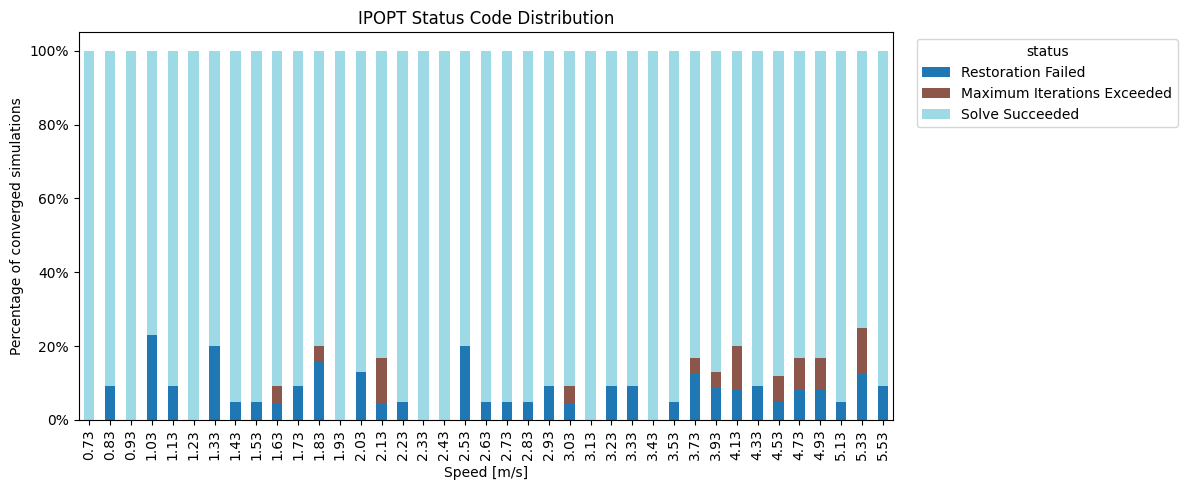

Percentage of converged simulations by msk_model
SIPP SmoothSphere                0.904899
SIPP SmoothSphere BhargavaAct    0.896956
SIPP SmoothSphere Stiffer4       0.833333
Unknown Model                    0.909091
Name: conv, dtype: float64
Percentage of converged simulations at speed < 2.75 m/s by msk_model
SIPP SmoothSphere                0.938967
SIPP SmoothSphere BhargavaAct    0.878788
Name: conv, dtype: float64
Percentage of converged simulations at speed >= 2.75 m/smsk_model
SIPP SmoothSphere                0.850746
SIPP SmoothSphere BhargavaAct    0.918367
SIPP SmoothSphere Stiffer4       0.833333
Unknown Model                    0.909091
Name: conv, dtype: float64


In [5]:
# First test: is convergence linked to speed?
# Make a stacked bar plot: 
# - Converged vs not converged
# - Converged by ipopt status code (info_.['status'])

df_plot = df.copy()#[df['msk_model'] == 'runmad_sipp']
df_plot['status'] = df_plot['info_'].apply(lambda x: x.get('status', np.nan))

# 2) Among converged runs: IPOPT status code distribution (stacked counts by speed)
status_counts = (
    df_plot
    .groupby(['speed', 'status'])
    .size()
    .unstack(fill_value=0)
    .sort_index(axis=1)
)
status_counts = status_counts.apply(lambda x: x / x.sum(), axis=1)
# Rename labels :
status_counts.columns = status_counts.columns.map({
    0: 'Solve Succeeded',
    1: 'Solved To Acceptable Level',
    2: 'Infeasible Problem Detected',
    3: 'Search_Direction_Becomes_Too_Small',        
    4: 'Diverging_Iterates',
    5: 'User_Requested_Stop',
    6: 'Feasible_Point_Found',
    -1: 'Maximum Iterations Exceeded',
    -2: 'Restoration Failed',
    -3: 'Error_In_Step_Computation',
    -4: 'Maximum_CpuTime_Exceeded', 
    -10: 'Not_Enough_Degrees_Of_Freedom',
    -11: 'Invalid_Problem_Definition',
    -12: 'Invalid_Option',
    -13: 'Invalid_Number_Detected',
    -100: 'Unrecoverable_Exception',
    -101: 'NonIpopt_Exception_Thrown',
    -102: 'Insufficient_Memory',
    -199: 'Internal_Error'
})


ax = status_counts.plot(kind='bar', stacked=True, figsize=(12, 5), colormap='tab20')
ax.set_xlabel('Speed [m/s]')
ax.set_ylabel('Percentage of converged simulations')
ax.set_title('IPOPT Status Code Distribution')
ax.set_xticklabels([f"{x:.2f}" for x in status_counts.index], rotation=90)
ax.set_yticklabels([f"{y:.0%}" for y in ax.get_yticks()])
ax.legend(title='status', bbox_to_anchor=(1.02, 1), loc='upper left')
# make 
plt.tight_layout()
plt.show()

df_plot['conv'] = df_plot['converged'].apply(lambda x: 1 if x in [1] else 0)
clean_data_percentage = df_plot.groupby('msk_model')['conv'].mean()
print("Percentage of converged simulations by ",end="")
print(clean_data_percentage)
print("Percentage of converged simulations at speed < 2.75 m/s by ",end="")
print(df_plot[df_plot['speed'] < 2.75].groupby('msk_model')['conv'].mean())
print("Percentage of converged simulations at speed >= 2.75 m/s",end="")
print(df_plot[df_plot['speed'] >= 2.75].groupby('msk_model')['conv'].mean())

/var/folders/zp/1cs5lqq978n6gd_m465gfm840000gn/T/ipykernel_14621/4165017679.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{y:.0%}" for y in ax.get_yticks()])


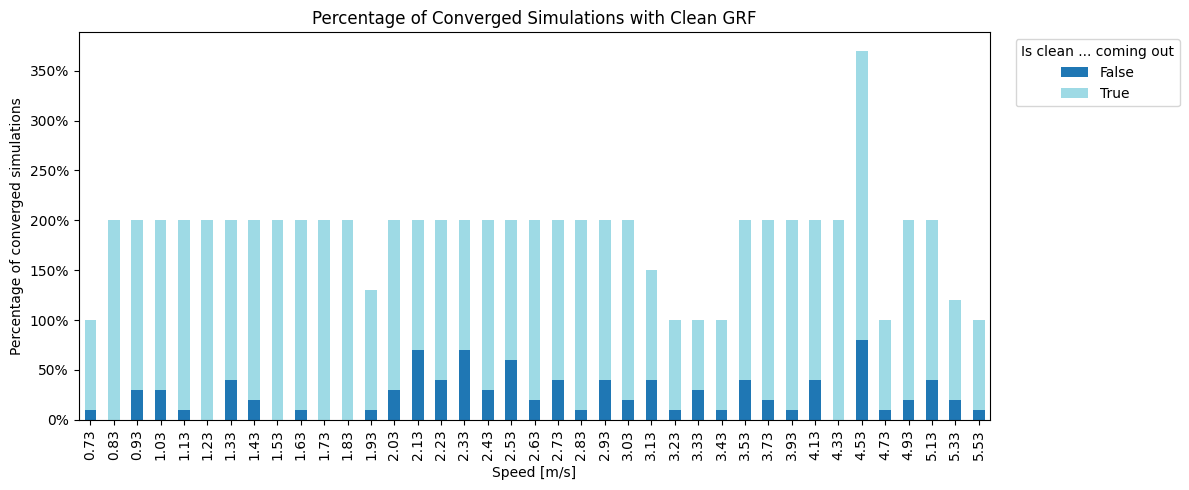

Percentage of clean data by msk_model
SIPP SmoothSphere                0.872611
SIPP SmoothSphere BhargavaAct    0.866841
SIPP SmoothSphere Stiffer4       0.500000
Unknown Model                    0.900000
Name: clean_data, dtype: float64
Percentage of clean data at speed < 2.75 m/s by msk_model
SIPP SmoothSphere                0.870000
SIPP SmoothSphere BhargavaAct    0.871921
Name: clean_data, dtype: float64
Percentage of clean data at speed >= 2.75 m/smsk_model
SIPP SmoothSphere                0.877193
SIPP SmoothSphere BhargavaAct    0.861111
SIPP SmoothSphere Stiffer4       0.500000
Unknown Model                    0.900000
Name: clean_data, dtype: float64


In [6]:
# step 1: filter only converged runs
df = df[df['converged'] == True]
# Then, filter by exclusion criteria (e.g. more than 1 grf peak)
def _is_not_2_peaks(threshold=0.1):
    grf_y = df['grf'].apply(lambda grf: grf['grf_y'].values)
    is_not_2_peaks = []
    for i in range(len(grf_y)):
        grf_ = grf_y.iloc[i].copy()
        grf_[grf_ < threshold] = 0
        grf_[grf_ >= threshold] = 1
        mask = np.diff(grf_)
        num_peaks = np.sum(mask > 0)
        is_not_2_peaks.append(num_peaks < 1)
    return np.array(is_not_2_peaks)

df_plot = df.copy()#[df['msk_model'] == 'runmad_sipp']

for speed in df_plot['speed'].unique():
    mean_metcost_per_speed = df_plot[df_plot['speed'] == speed]['metabolicCostBhargava'].mean()
    std_metcost_per_speed = df_plot[df_plot['speed'] == speed]['metabolicCostBhargava'].std()
    upper = mean_metcost_per_speed + 2 * std_metcost_per_speed
    df_plot.loc[df_plot['speed'] == speed, 'upper'] = upper

df_plot['clean_data'] = _is_not_2_peaks() & (df_plot['metabolicCostBhargava'] <= df_plot['upper'])

status_counts = (
    df_plot
    .groupby(['speed', 'clean_data'])
    .size()
    .unstack(fill_value=0)
    .sort_index(axis=1)
)
status_counts = status_counts.apply(lambda x: x / 10, axis=1)
ax = status_counts.plot(kind='bar', stacked=True, figsize=(12, 5), colormap='tab20')#,hue='msk_model')
ax.set_xlabel('Speed [m/s]')
ax.set_ylabel('Percentage of converged simulations')
ax.set_title('Percentage of Converged Simulations with Clean GRF')
ax.set_xticklabels([f"{x:.2f}" for x in status_counts.index], rotation=90)
ax.set_yticklabels([f"{y:.0%}" for y in ax.get_yticks()])
ax.legend(title='Is clean ... coming out', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Print-summarize the percentage of clean data by msk_model
clean_data_percentage = df_plot.groupby('msk_model')['clean_data'].mean()
print("Percentage of clean data by ",end="")
print(clean_data_percentage)
print("Percentage of clean data at speed < 2.75 m/s by ",end="")
print(df_plot[df_plot['speed'] < 2.75].groupby('msk_model')['clean_data'].mean())
print("Percentage of clean data at speed >= 2.75 m/s",end="")
print(df_plot[df_plot['speed'] >= 2.75].groupby('msk_model')['clean_data'].mean())
df = df[df_plot['clean_data'] == True]



## 2: Iterations and Durations

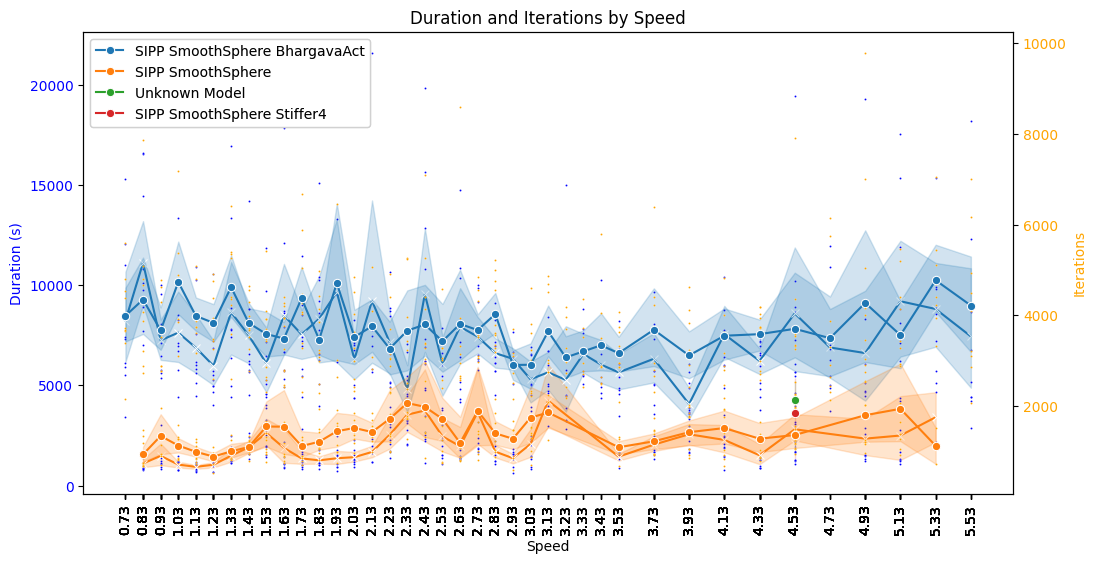

In [7]:
df2 = df.copy()
df2['duration'] = df2['info_'].apply(lambda x: x['wallTime'])
df2['iterations'] = df2['info_'].apply(lambda x: x['iter'])

# Plot duration with the y-labels on the left side
# Then plot iterations with the y-labels on the right side
fig, ax1 = plt.subplots(figsize=(12, 6))
sns.lineplot(x='speed', y='duration', data=df2, marker='x', ax=ax1, hue='msk_model', palette='tab10')
sns.scatterplot(x='speed', y='duration', data=df2, ax=ax1, color='blue', s=2)
ax1.set_xlabel('Speed')
ax1.set_ylabel('Duration (s)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticks(df2['speed'])
plt.xticks(rotation=90)
ax1.set_xticklabels([f"{x:.2f}" for x in df2['speed']])
ax1.set_title('Duration and Iterations by Speed')
ax2 = ax1.twinx()
sns.lineplot(x='speed', y='iterations', data=df2, marker='o', ax=ax2, color='orange', hue='msk_model')
sns.scatterplot(x='speed', y='iterations', data=df2, ax=ax2, color='orange', s=2)
ax2.set_ylabel('Iterations', color='orange')

ax2.tick_params(axis='y', labelcolor='orange')
plt.show()
# print average iteration advantage for smoothsphere

## 3: Objective Values by speed

/var/folders/zp/1cs5lqq978n6gd_m465gfm840000gn/T/ipykernel_14621/1468532149.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df2['VAE'][df2['msk_model'] == 'Generic, Effort 2'] *=3
/var/folders/zp/1cs5lqq978n6gd_m465gfm840000gn/T/ipykerne

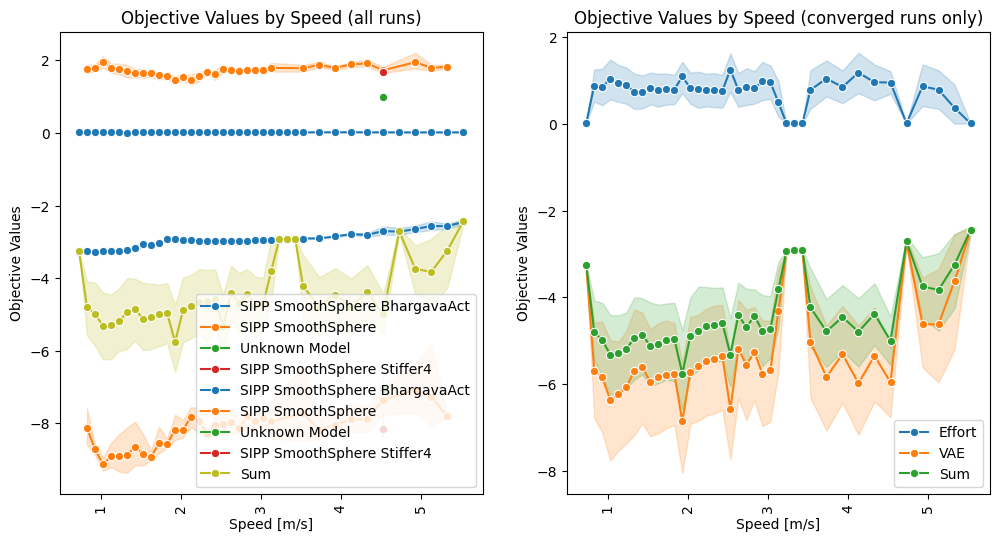

In [8]:
fig = plt.figure(figsize=(12, 6))
fig.add_subplot(1, 2, 1)
df2 = df.copy()#[df.converged == True]
df2['Effort'] = df2['objectives'].apply(lambda x: sum([obj['weightedValue'] for obj in x if obj['name'] in ['effortTermMusclesAct',"effortTermTorques"]]))
df2['VAE'] = df2['objectives'].apply(lambda x: sum([obj['weightedValue'] for obj in x if obj['name'] == 'vaeReconstructionTerm']))
df2['VAE'][df2['msk_model'] == 'Generic, Effort 2'] *=3
df2['sum'] = df2['Effort'] + df2['VAE']
sns.lineplot(x='speed', y='Effort', data=df2, marker='o', hue='msk_model')
sns.lineplot(x='speed', y='VAE', data=df2, marker='o', hue = 'msk_model')
sns.lineplot(x='speed', y='sum', data=df2, marker='o', label='Sum')
plt.xlabel('Speed [m/s]')
plt.ylabel('Objective Values')
plt.title('Objective Values by Speed (all runs)')
plt.legend()
plt.xticks(rotation=90)
fig.add_subplot(1, 2, 2)
df2 = df2[df2['converged'] == True]
sns.lineplot(x='speed', y='Effort', data=df2, marker='o', label='Effort')
sns.lineplot(x='speed', y='VAE', data=df2, marker='o', label='VAE')
sns.lineplot(x='speed', y='sum', data=df2, marker='o', label='Sum')
plt.xlabel('Speed [m/s]')
plt.ylabel('Objective Values')
plt.title('Objective Values by Speed (converged runs only)')
plt.legend()
plt.xticks(rotation=90)
plt.show()

## 4: Metabolic Costs, Durations

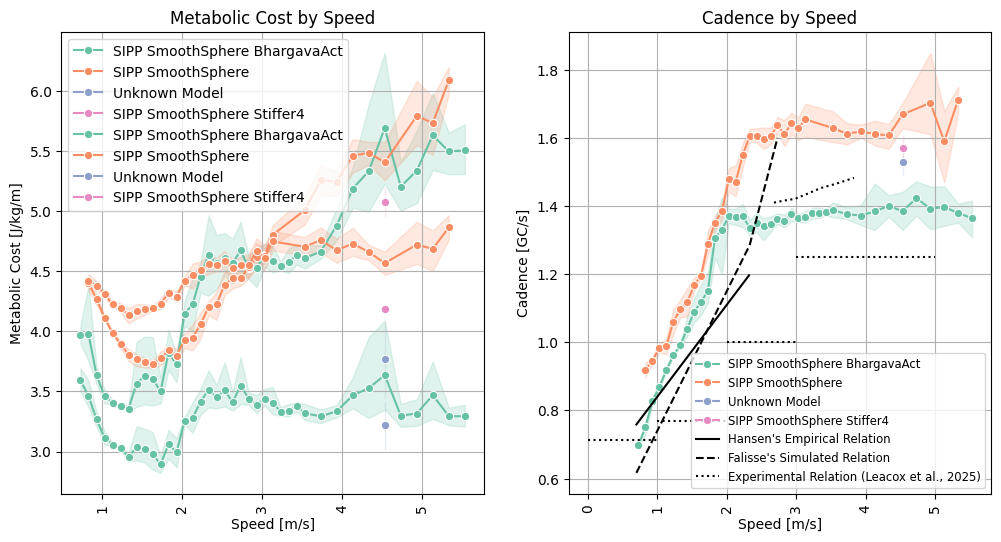

In [9]:
fig = plt.figure(figsize=(12, 6)) 
fig.add_subplot(1, 2, 1)
basal_metabolic = 1.2 # W / kg
metcost_incl_basal = basal_metabolic / (df2['speed']) + df2['metabolicCost']
sns.lineplot(x='speed', y="metabolicCost", marker='o', data=df2, palette='Set2', hue='msk_model')
sns.lineplot(x='speed', y="metabolicCostBhargava", marker='o', data=df2, palette='Set2', hue='msk_model')



#sns.lineplot(x='speed', y=metcost_incl_basal, data=df2, marker='o', label='Metabolic Cost (Incl. Basal)', color='black', linestyle='--')
plt.xlabel('Speed [m/s]')
plt.ylabel('Metabolic Cost [J/kg/m]')
plt.title('Metabolic Cost by Speed')
plt.legend()
plt.xticks(rotation=90)
plt.grid()
fig.add_subplot(1, 2, 2)
#sns.lineplot(x='speed', y='dur', data=df2, marker='o', label='All Runs')
#sns.lineplot(x='speed', y='dur', data=df2[df2['converged'] == True], marker='o', label='Converged Runs Only')
df2['cadence'] = 1 / (df2['dur']*2)
sns.lineplot(x='speed', y='cadence', data=df2, marker='o', hue='msk_model', palette='Set2')
plt.plot(np.arange(0.7,2.33,0.01), np.arange(0.7,2.33,0.01)*0.27+0.57, label="Hansen's Empirical Relation", color='black')
plt.plot(np.arange(0.7,2.33,0.01), np.arange(0.7,2.33,0.01)*0.41+0.33, linestyle='--', label="Falisse's Simulated Relation", color='black')
plt.plot([2.33,2.73], [0.41*2.33+0.33, 1.6], linestyle='--', color='black')
plt.plot([2.68,2.82,2.98,3.16,3.35,3.58,3.83], np.array([169.2,169.9,170.5,172.3,174.3,175.9,177.9])/60/2, label="Experimental Relation (Leacox et al., 2025)", color='black', linestyle=':')
plt.xlabel('Speed [m/s]')
plt.ylabel('Cadence [GC/s]')
plt.title('Cadence by Speed')
plt.legend(loc='lower right', fontsize='small')
# bounds
plt.plot([0,1], np.ones(2)/0.7/2, color='black', linestyle=':')
plt.plot([1,2], np.ones(2)/0.65/2, color='black', linestyle=':')
plt.plot([2,3], np.ones(2)/0.5/2, color='black', linestyle=':')
plt.plot([3,5], np.ones(2)/0.4/2, color='black', linestyle=':')

#plt.plot(np.arange(0.7,3,0.01), np.arange(0.7,3,0.01)*0.27+0.37, color='black')

#plt.xlim(0.65, 3.6)
plt.xticks(rotation=90)
plt.grid()
plt.show()

# Chapter 2: Angles & GRF patterns
Searching for that walk-to-run transition in the GRF patterns

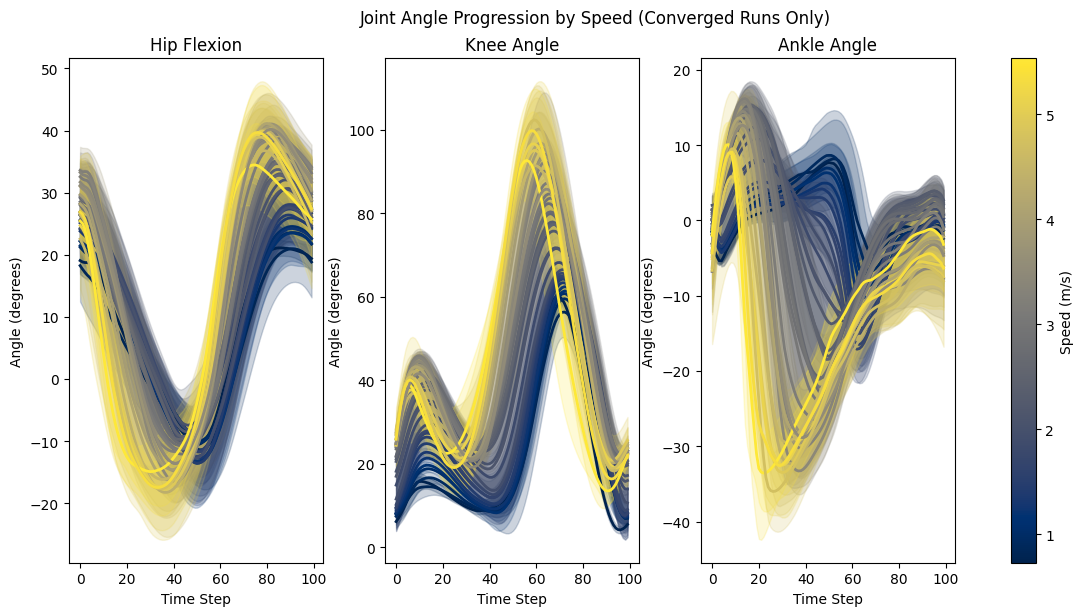

In [10]:
# Plot hip, knee and ankle progression by speed, for converged runs only
df2 = df.copy()
fig = plt.figure(figsize=(12, 6))
cmap = plt.get_cmap('cividis')
#df2 = df2[df2['speed'] < 1.8]
norm = plt.Normalize(vmin=df2['speed'].min(), vmax=df2['speed'].max())
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
for i, joint in enumerate(['hip_flexion', 'knee_angle', 'ankle_angle']):
    plt.subplot(1, 3, i+1)
    for speed in df2['speed'].unique():
        subset = df2[(df2['speed'] == speed) & (df2['converged'] == True)]
        if not subset.empty:
            list_of_angles = [row['angles'][joint] for i,row in subset.iterrows()]
            mean_angles = np.mean(list_of_angles, axis=0) * 180/np.pi
            std_angles = np.std(list_of_angles, axis=0) * 180/np.pi
        else: 
            continue
        if joint == "knee_angle":
            mean_angles *= -1
        plt.plot(mean_angles, label=f'{speed:.2f} m/s', linewidth=2, color=cmap(norm(speed)))
        plt.fill_between(range(len(mean_angles)), mean_angles-std_angles, mean_angles+std_angles, alpha=0.2, color=cmap(norm(speed)))
    plt.title(joint.replace('_', ' ').title())
    plt.xlabel('Time Step')
    plt.ylabel('Angle (degrees)')
plt.tight_layout()
plt.colorbar(sm, ax=fig.get_axes(), orientation='vertical', label='Speed (m/s)')
plt.suptitle('Joint Angle Progression by Speed (Converged Runs Only)', y=1.02)
plt.show()

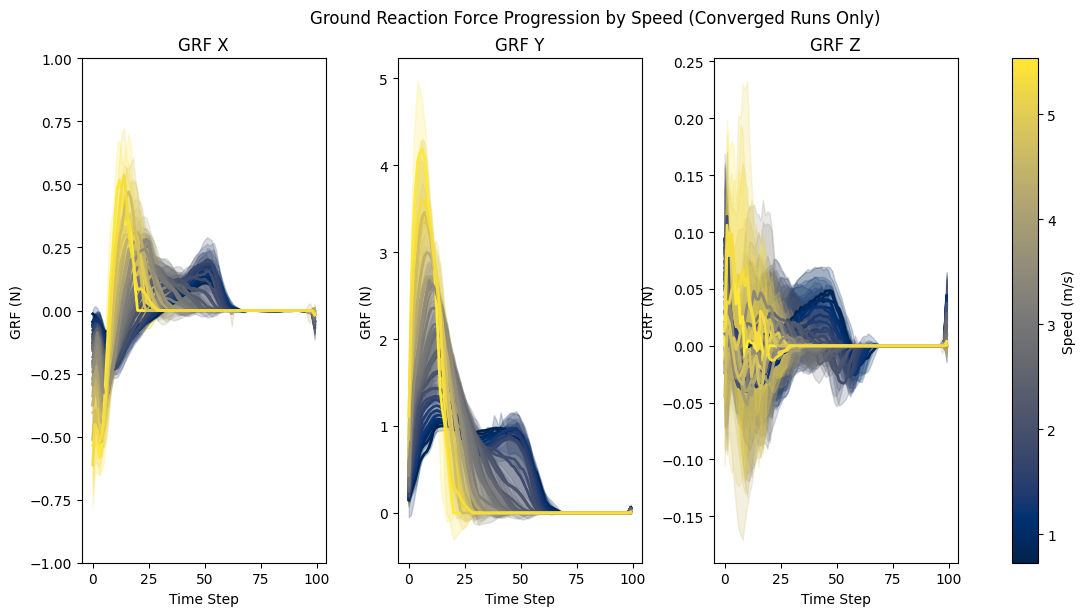

Speed 0.73 m/s has significant GRF at time step 50: 0.905 BW
Speed 0.83 m/s has significant GRF at time step 50: 0.823 BW
Speed 0.93 m/s has significant GRF at time step 50: 0.883 BW
Speed 1.03 m/s has significant GRF at time step 50: 0.885 BW
Speed 1.13 m/s has significant GRF at time step 50: 0.902 BW
Speed 1.23 m/s has significant GRF at time step 50: 0.891 BW
Speed 1.33 m/s has significant GRF at time step 50: 0.876 BW
Speed 1.43 m/s has significant GRF at time step 50: 0.857 BW
Speed 1.53 m/s has significant GRF at time step 50: 0.741 BW
Speed 1.63 m/s has significant GRF at time step 50: 0.774 BW
Speed 1.73 m/s has significant GRF at time step 50: 0.749 BW
Speed 1.83 m/s has significant GRF at time step 50: 0.413 BW
Speed 1.93 m/s has significant GRF at time step 50: 0.515 BW
Speed 2.03 m/s has significant GRF at time step 50: 0.213 BW
Speed 2.13 m/s has significant GRF at time step 50: 0.201 BW


In [11]:
# Same for GRF patterns
fig = plt.figure(figsize=(12, 6))
cmap = plt.get_cmap('cividis')
norm = plt.Normalize(vmin=df2['speed'].min(), vmax=df2['speed'].max())
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
for i, axis in enumerate(['x', 'y', 'z']): 
    plt.subplot(1, 3, i+1)
    for speed in df2['speed'].unique():
        subset = df2[(df2['speed'] == speed) & (df2['converged'] == True)]
        if not subset.empty:
            list_of_grf = [row['grf'][f'grf_{axis}'] for i,row in subset.iterrows()]
            mean_grf = np.mean(list_of_grf, axis=0)
            std_grf = np.std(list_of_grf, axis=0)
        else: 
            continue
        plt.plot(mean_grf, label=f'{speed:.2f} m/s', linewidth=2, color=cmap(norm(speed)))
        plt.fill_between(range(len(mean_grf)), mean_grf-std_grf, mean_grf+std_grf, alpha=0.2, color=cmap(norm(speed)))
    plt.title(f'GRF {axis.upper()}')
    plt.xlabel('Time Step')
    plt.ylabel('GRF (N)')
    if axis == 'x':
        plt.ylim(-1,1)
plt.tight_layout()
plt.suptitle('Ground Reaction Force Progression by Speed (Converged Runs Only)', y=1.02)
plt.colorbar(sm, ax=fig.get_axes(), orientation='vertical', label='Speed (m/s)')
plt.show()  
# List all the speeds that still have significant GRF in the y-axis at the 50th time step (which should be around the middle of the gait cycle)
for speed in df2['speed'].unique():
    subset = df2[(df2['speed'] == speed) & (df2['converged'] == True)]
    if not subset.empty:
        list_of_grf = [row['grf']['grf_y'] for i,row in subset.iterrows()]
        mean_grf = np.mean(list_of_grf, axis=0)
        if mean_grf[50] > 0.1:
            print(f'Speed {speed:.2f} m/s has significant GRF at time step 50: {mean_grf[50]:.3f} BW')

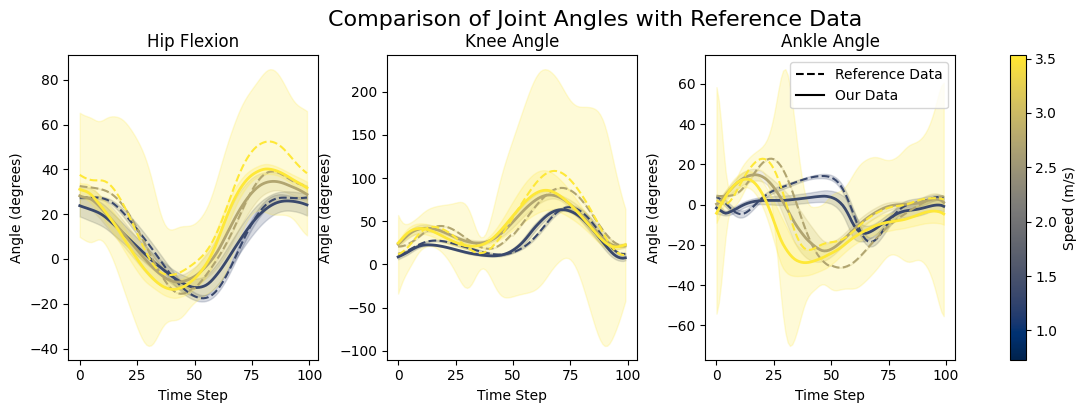

In [12]:
#plot ours against reference data: reference_data/Falisse201
fig = plt.figure(figsize=(12, 4))
cmap = plt.get_cmap('cividis')
norm = plt.Normalize(vmin=df2['speed'].min(), vmax=3.53)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)

exp_data = loadmat('/Users/markusgambietz/Downloads/3dpredictsim/OpenSimModel/subject1/IK/IK_average_running_HGC.mat', squeeze_me=True, simplify_cells=True)
joint_indices = {
    "hip_flexion_r": 6,
    "knee_angle_r": 9,
    "ankle_angle_r": 10,
    "hip_flexion_l": 13,
    "knee_angle_l": 16,
    "ankle_angle_l": 17
}
joint_indices_falisse = {
    "hip_flexion": 9,
    "knee_angle": 13,
    "ankle_angle": 15
}
exp_data_falisse_2_73 = np.vstack((exp_data['Qsall']['data'][:,[10,14,16]],exp_data['Qsall']['data'][:,[7,13,15]]))

fukuchi_path_mean = "reference_data/Fukuchi_35_mean.mat"
fukuchi_path_var = "reference_data/Fukuchi_35_var.mat"
fukuchi_mean = loadmat(fukuchi_path_mean, squeeze_me=True, simplify_cells=True)['arr']
fukuchi_var = loadmat(fukuchi_path_var, squeeze_me=True, simplify_cells=True)['arr']

exp_data = loadmat('/Users/markusgambietz/Downloads/3dpredictsim/ExperimentalData/ExperimentalData.mat', squeeze_me=True, simplify_cells=True)
falisse_mean = exp_data['ExperimentalData']['Q']['subject1']['Qs']['mean'][:,[6,9,10]]  # Hip, Knee, Ankle
falisse_std = exp_data['ExperimentalData']['Q']['subject1']['Qs']['std'][:,[6,9,10]]  # Hip, Knee, Ankle


for i, joint in enumerate(['hip_flexion', 'knee_angle', 'ankle_angle']):
    plt.subplot(1, 3, i+1)
    for speed, (mean_data, std_data) in zip([1.33,2.73,3.53],[[falisse_mean, falisse_std], [exp_data_falisse_2_73, np.zeros_like(exp_data_falisse_2_73)], [fukuchi_mean.T*180/np.pi, fukuchi_var.T*(180/np.pi)**2]]):
        subset = df2[np.isclose(df2['speed'], speed) & (df2['converged'] == True)]
        if not subset.empty:
            list_of_angles = [row['angles'][joint] for i,row in subset.iterrows()]
            mean_angles = np.mean(list_of_angles, axis=0) * 180/np.pi
            std_angles = np.std(list_of_angles, axis=0) * 180/np.pi
        else: 
            continue
        if joint == "knee_angle":
            mean_angles *= -1
            std_angles *= -1
            mean_data[:,i] *= -1
        plt.plot(mean_angles, linewidth=2, color=cmap(norm(speed)))
        plt.fill_between(range(len(mean_angles)), mean_angles-std_angles, mean_angles+std_angles, alpha=0.2, color=cmap(norm(speed)))

        plt.plot(mean_data[:,i], linestyle='--', color=cmap(norm(speed)))
        plt.fill_between(range(len(mean_data[:,i])), mean_data[:,i]-std_data[:,i], mean_data[:,i]+std_data[:,i], alpha=0.2, color=cmap(norm(speed)))
    plt.title(joint.replace('_', ' ').title())
    plt.xlabel('Time Step')
    plt.ylabel('Angle (degrees)')
# Make a legend that shows -- is reference data and solid line is our data
handles, labels = plt.gca().get_legend_handles_labels()
plt.plot([0,0], [0,0], color='black', label='Reference Data', linestyle='--', alpha=1)
plt.plot([0,0], [0,0], color='black', label='Our Data', linestyle='-', alpha=1)
plt.legend(loc='upper right')
plt.tight_layout()
plt.colorbar(sm, ax=fig.get_axes(), orientation='vertical', label='Speed (m/s)')
plt.suptitle('Comparison of Joint Angles with Reference Data', fontsize=16, y=1.02)
plt.show()

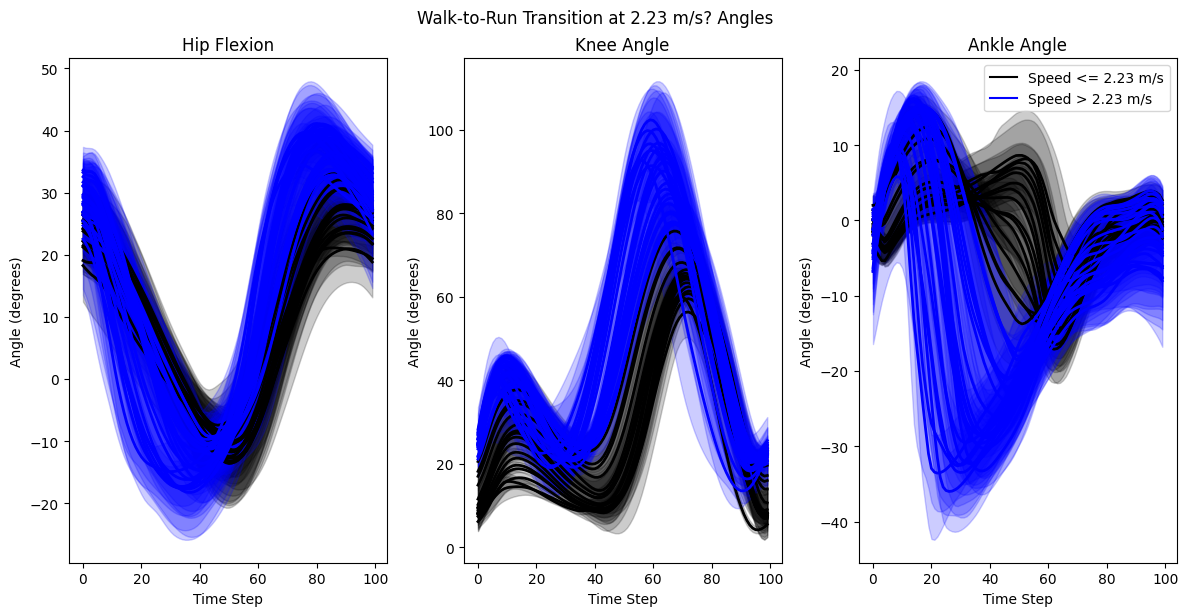

In [86]:
df2 = df[df['converged'] == True].copy()
fig = plt.figure(figsize=(12, 6))
cmap1 = plt.get_cmap('cividis')
cmap2 = plt.get_cmap('plasma')
norm = plt.Normalize(vmin=df2['speed'].min(), vmax=2.23)
norm2 = plt.Normalize(vmin=2.23, vmax=df2['speed'].max())
sm = plt.cm.ScalarMappable(cmap=cmap1, norm=norm)
sm2 = plt.cm.ScalarMappable(cmap=cmap2, norm=norm2)
for i, joint in enumerate(['hip_flexion', 'knee_angle', 'ankle_angle']):
    plt.subplot(1, 3, i+1)
    for speed in df2['speed'].unique():
        subset = df2[(df2['speed'] == speed) & (df2['converged'] == True)]
        if not subset.empty:
            list_of_angles = [row['angles'][joint] for i,row in subset.iterrows()]
            mean_angles = np.mean(list_of_angles, axis=0) * 180/np.pi
            std_angles = np.std(list_of_angles, axis=0) * 180/np.pi
        else: 
            continue
        if joint == "knee_angle":
            mean_angles *= -1
        if speed <= 2.23:
            c = "black"
        else:
            c = "blue"
        plt.plot(mean_angles, label=f'{speed:.2f} m/s', linewidth=2, color=c)
        plt.fill_between(range(len(mean_angles)), mean_angles-std_angles, mean_angles+std_angles, alpha=0.2, color=c)
    plt.title(joint.replace('_', ' ').title())
    plt.xlabel('Time Step')
    plt.ylabel('Angle (degrees)')
plt.tight_layout()
# make a legend that shows blue is above 2.23 m/s and black is below 2.23 m/s
plt.plot([0,0], [0,0], color='black', label='Speed <= 2.23 m/s', linestyle='-', alpha=1)
plt.plot([0,0], [0,0], color='blue', label='Speed > 2.23 m/s', linestyle='-', alpha=1)
# remove all other labels from the legend
handles, labels = plt.gca().get_legend_handles_labels()
handles = [handles[-2], handles[-1]]
labels = [labels[-2], labels[-1]]
plt.legend(loc='upper right', handles=handles, labels=labels)
plt.suptitle('Walk-to-Run Transition at 2.23 m/s? Angles', y=1.02)
plt.show()

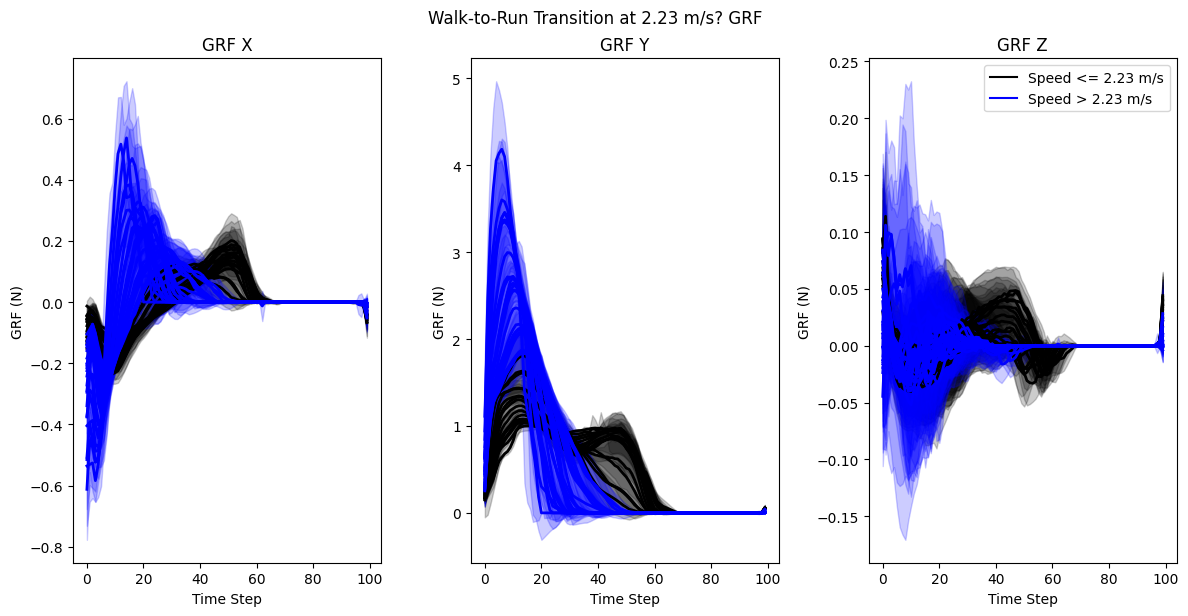

Speed 0.73 m/s has significant GRF at time step 50: 0.905 BW
Speed 0.83 m/s has significant GRF at time step 50: 0.823 BW
Speed 0.93 m/s has significant GRF at time step 50: 0.883 BW
Speed 1.03 m/s has significant GRF at time step 50: 0.885 BW
Speed 1.13 m/s has significant GRF at time step 50: 0.902 BW
Speed 1.23 m/s has significant GRF at time step 50: 0.891 BW
Speed 1.33 m/s has significant GRF at time step 50: 0.876 BW
Speed 1.43 m/s has significant GRF at time step 50: 0.857 BW
Speed 1.53 m/s has significant GRF at time step 50: 0.741 BW
Speed 1.63 m/s has significant GRF at time step 50: 0.774 BW
Speed 1.73 m/s has significant GRF at time step 50: 0.749 BW
Speed 1.83 m/s has significant GRF at time step 50: 0.413 BW
Speed 1.93 m/s has significant GRF at time step 50: 0.515 BW
Speed 2.03 m/s has significant GRF at time step 50: 0.213 BW
Speed 2.13 m/s has significant GRF at time step 50: 0.201 BW


In [87]:
# Same for GRF patterns
fig = plt.figure(figsize=(12, 6))
cmap = plt.get_cmap('cividis')
norm = plt.Normalize(vmin=df2['speed'].min(), vmax=df2['speed'].max())
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
for i, axis in enumerate(['x', 'y', 'z']): 
    plt.subplot(1, 3, i+1)
    for speed in df2['speed'].unique():
        subset = df2[(df2['speed'] == speed) & (df2['converged'] == True)]
        if not subset.empty:
            list_of_grf = [row['grf'][f'grf_{axis}'] for i,row in subset.iterrows()]
            mean_grf = np.mean(list_of_grf, axis=0)
            std_grf = np.std(list_of_grf, axis=0)
        else: 
            continue
        if speed <= 2.23:
            c = "black"
        else:            
            c = "blue"
        plt.plot(mean_grf, label=f'{speed:.2f} m/s', linewidth=2, color=c)
        plt.fill_between(range(len(mean_grf)), mean_grf-std_grf, mean_grf+std_grf, alpha=0.2, color=c)
    plt.title(f'GRF {axis.upper()}')
    plt.xlabel('Time Step')
    plt.ylabel('GRF (N)')
plt.tight_layout()
plt.suptitle('Walk-to-Run Transition at 2.23 m/s? GRF', y=1.02)
plt.plot([0,0], [0,0], color='black', label='Speed <= 2.23 m/s', linestyle='-', alpha=1)
plt.plot([0,0], [0,0], color='blue', label='Speed > 2.23 m/s', linestyle='-', alpha=1)
handles, labels = plt.gca().get_legend_handles_labels()
handles = [handles[-2], handles[-1]]
labels = [labels[-2], labels[-1]]
plt.legend(loc='upper right', handles=handles, labels=labels)
plt.show()  
# List all the speeds that still have significant GRF in the y-axis at the 50th time step (which should be around the middle of the gait cycle)
for speed in df2['speed'].unique():
    subset = df2[(df2['speed'] == speed) & (df2['converged'] == True)]
    if not subset.empty:
        list_of_grf = [row['grf']['grf_y'] for i,row in subset.iterrows()]
        mean_grf = np.mean(list_of_grf, axis=0)
        if mean_grf[50] > 0.1:
            print(f'Speed {speed:.2f} m/s has significant GRF at time step 50: {mean_grf[50]:.3f} BW')

In [88]:
df[df.msk_model == 'Gait3D_Bhargava'].sort_values('speed')[['speed', 'metabolicCostBhargava']]

,speed,metabolicCostBhargava


interactive(children=(FloatSlider(value=1.33, description='speed', max=5.529999999999999, min=0.73), Output())…

<function __main__.plot_variability(speed)>

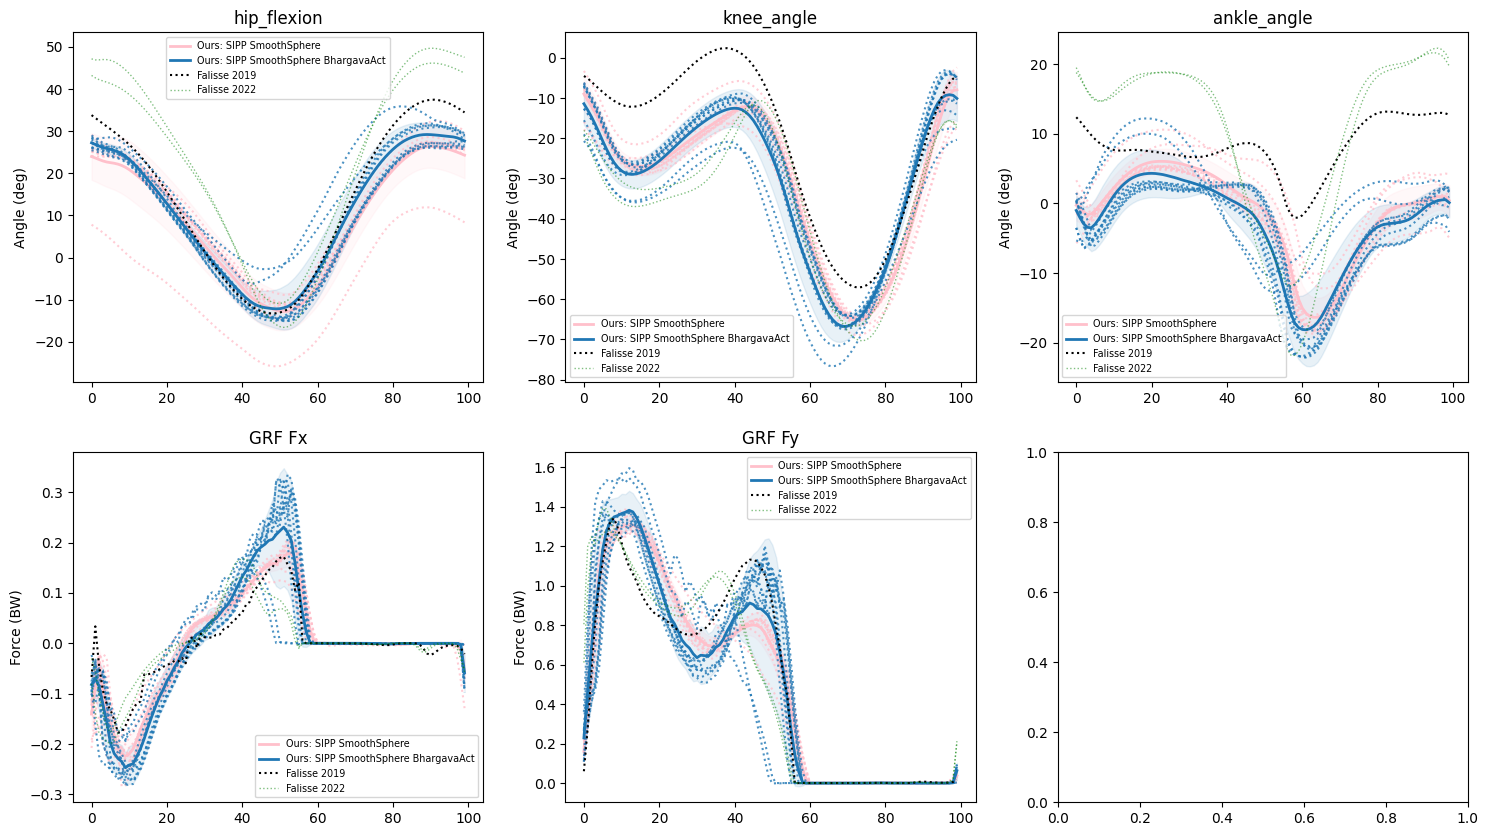

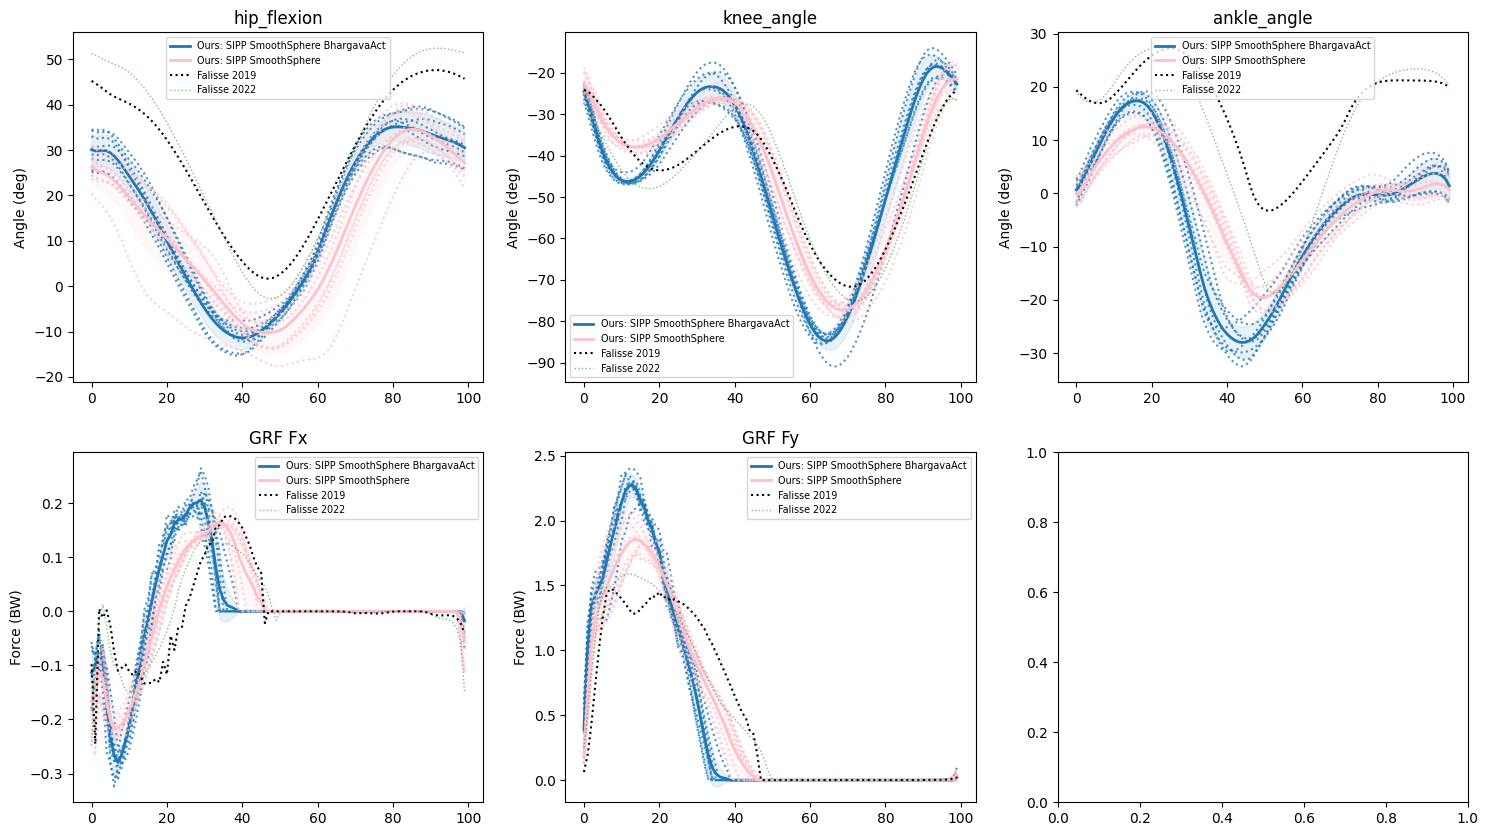

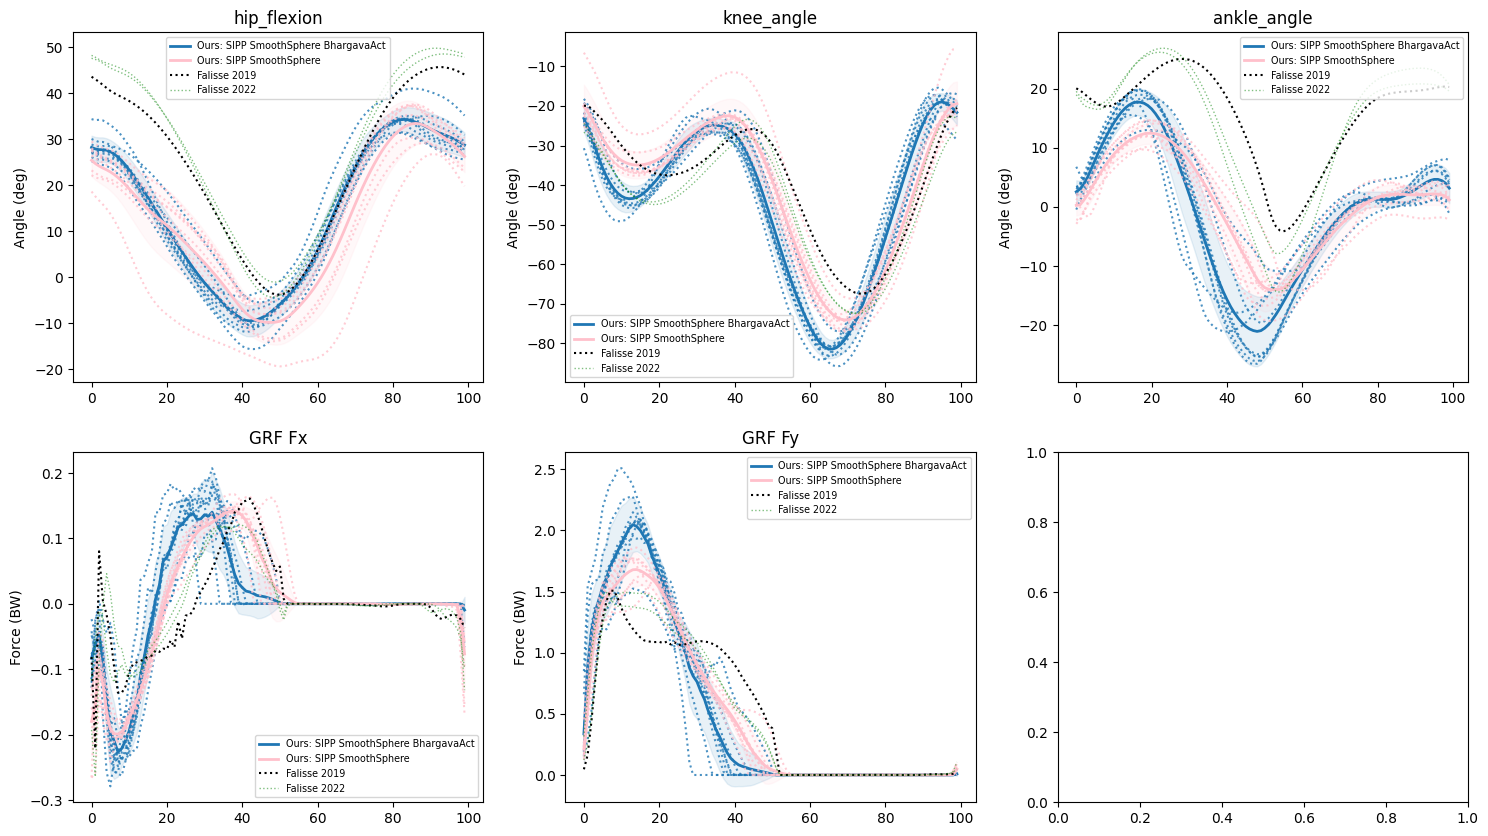

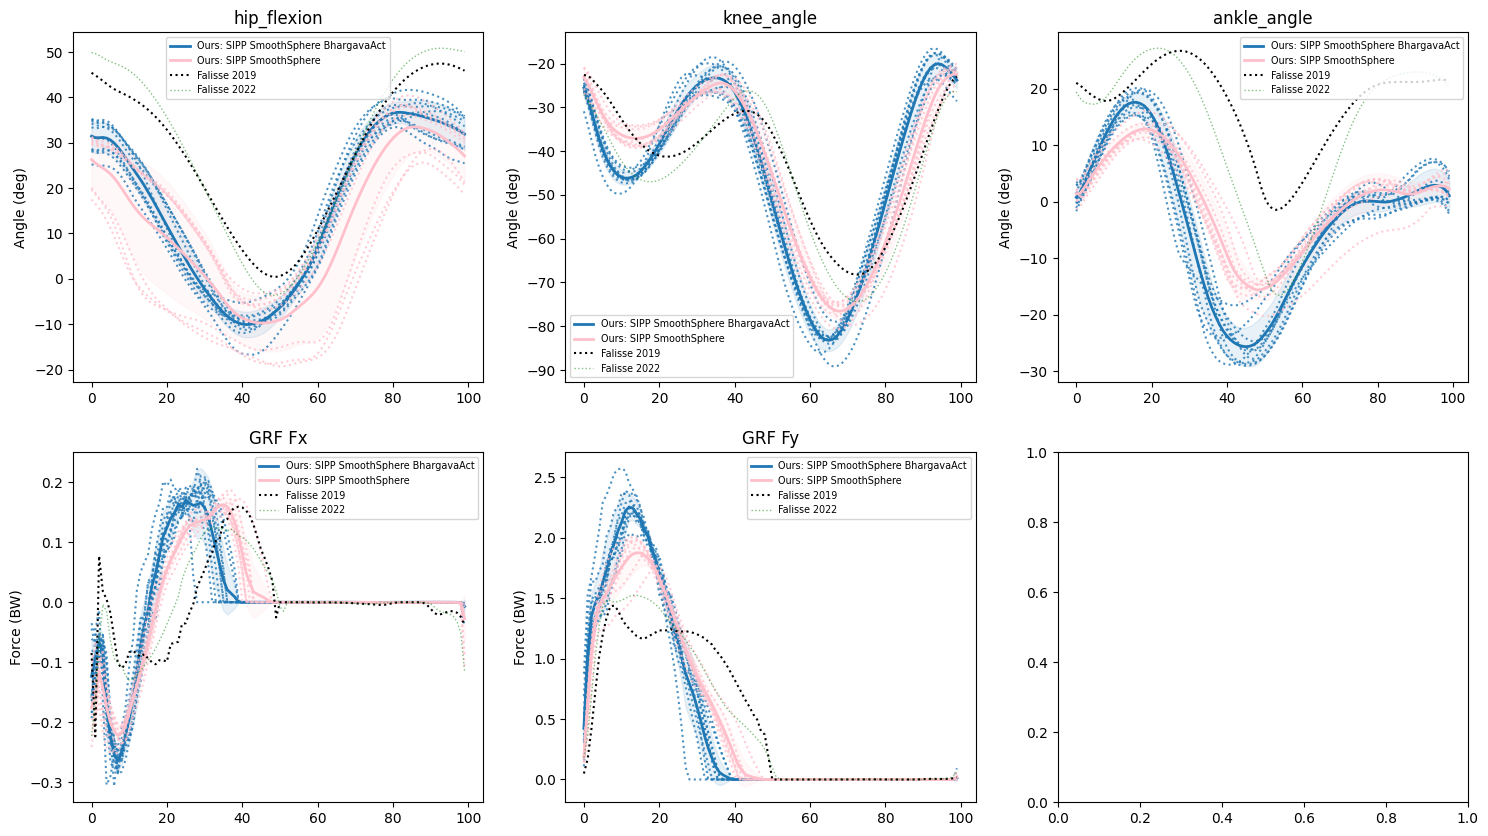

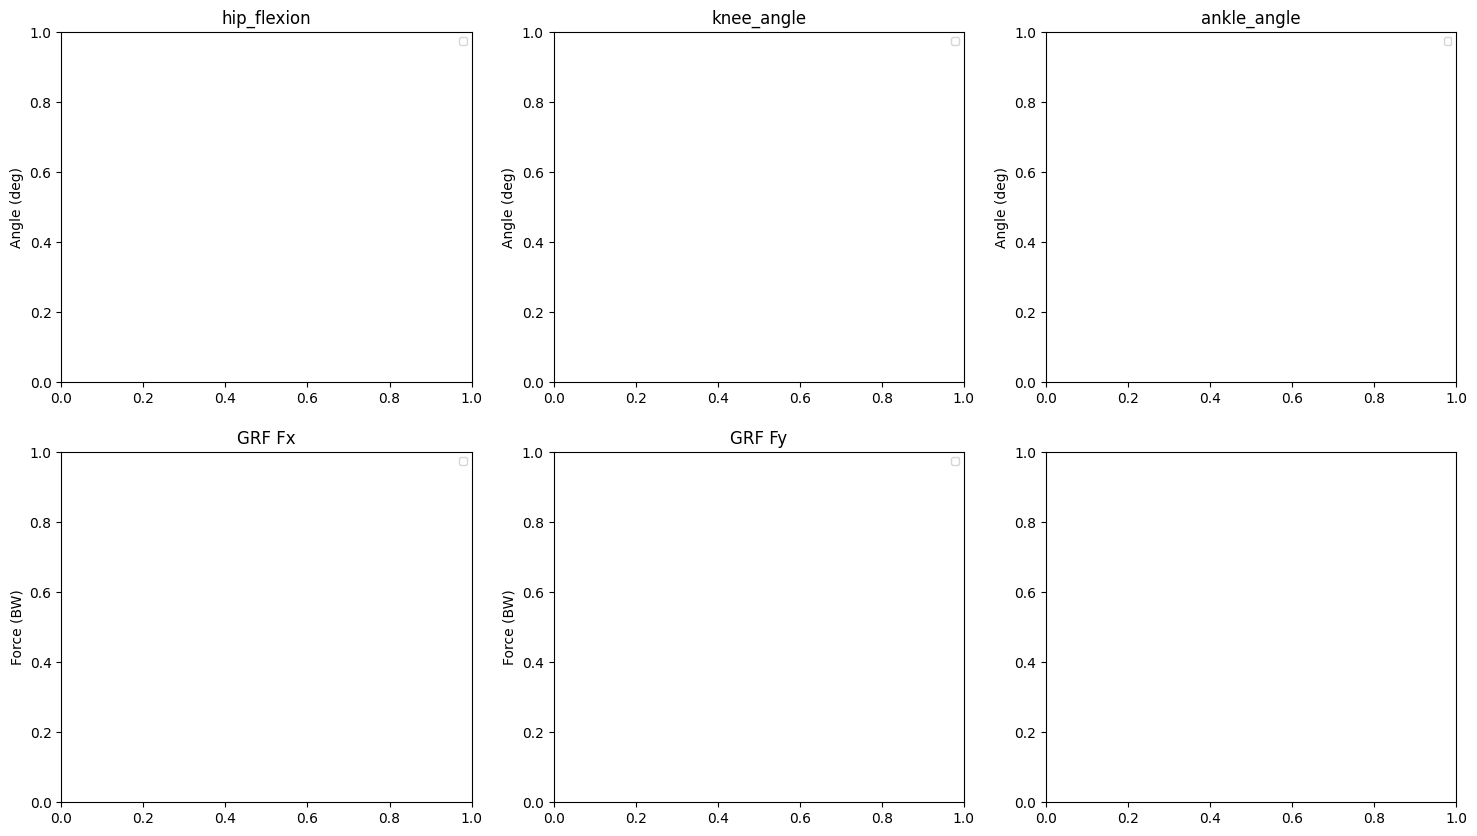

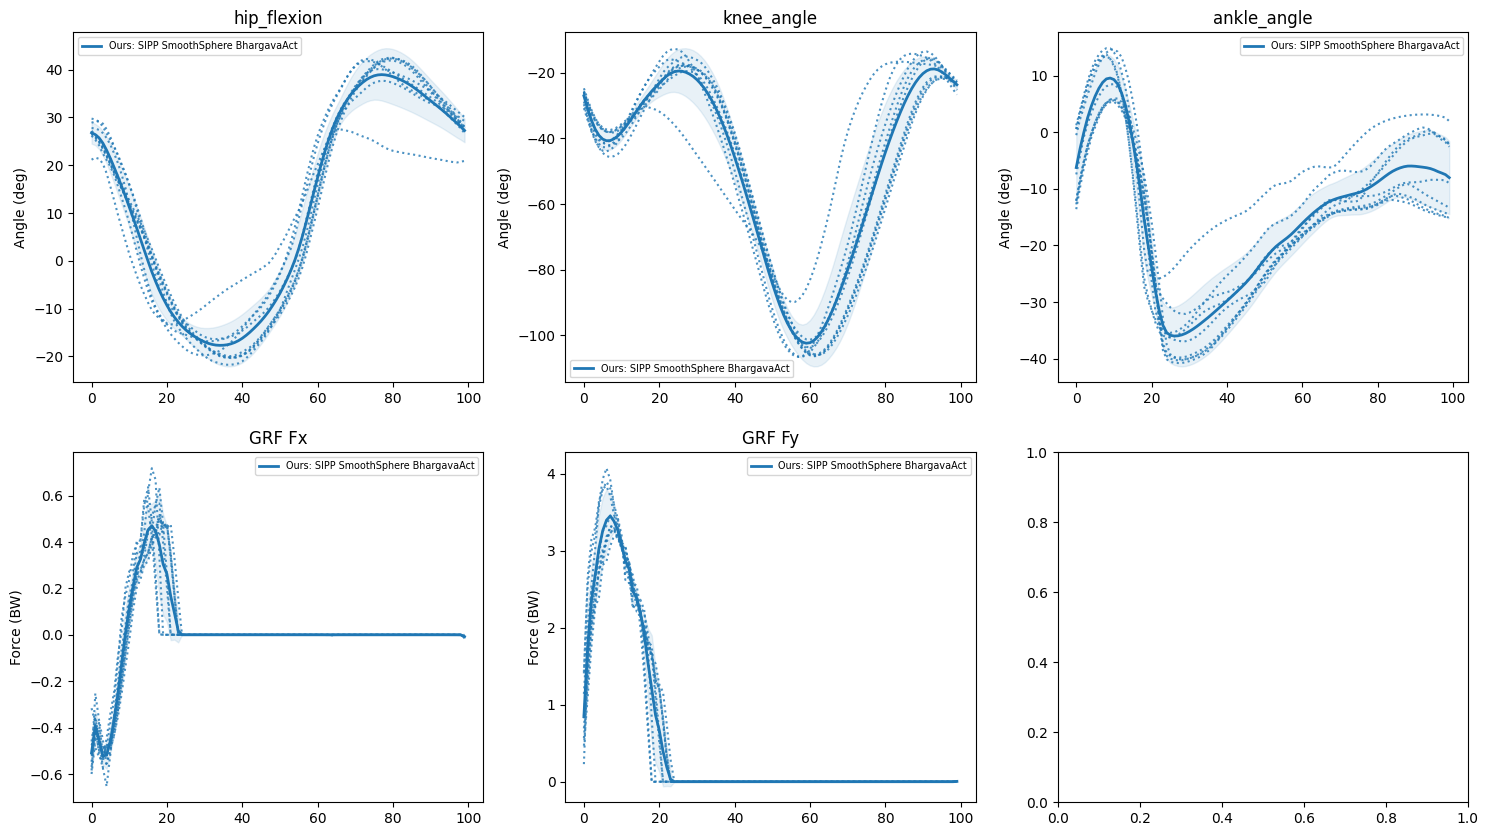

In [ ]:
# In-depth: variability
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
from scipy.io import loadmat
from ipywidgets import interact, FloatSlider

import gait_metrics as gm

colors_dict = {
    'Gait3D': 'blue',
    'VAE=1': 'orange',
    'RunMad_SIPP': 'green',
    'Gait3D_Bhargava': 'red',
    'SIPP': 'purple',
    'Falisse 2019': 'black',
    'Gait3D_Pelvis213_SmoothSphere': 'cyan',
    'Gait3D_Pelvis213_6Contacts': 'magenta',
    'SIPP SmoothSphere': 'pink',
    'SIPP SmoothSphere Houdijk': 'pink',
    'SIPP SmoothSphere Umberger': 'brown',
    'SIPP SmoothSphere Bhargava': 'magenta',
    'SIPP SmoothSphere SoftDamp2': 'lightblue',
    'SIPP SmoothSphere SoftDamp4': 'lightgreen',
    'SIPP SmoothSphere Stiffer2': 'lightcoral',
    'SIPP SmoothSphere Stiffer4': 'pink'
}

# Falisse 2019 benchmark loader now lives in gait_loading.get_falisse_sim.
from gait_loading import get_falisse_sim

def plot_variability(speed):
    subset = df2[np.isclose(df2.speed, speed)]
    subset = subset[subset['converged'] == True]
    #subset = subset[subset['is_walking'] == True]

    # 1. Get Reference Data
    ref_data = get_reference_data(speed)
    if ref_data:
        # User feedback: "you take the gait reference data's knee angle the wrong way"
        # data_utils already inverts it, but if it's still wrong, we might need to invert it back
        # or check if the model data flip was redundant.
        # Let's keep the ref as provided by get_reference_data for now but use a unified alignment.
        ref_angles = np.array([ref_data['hip']['mean'], ref_data['knee']['mean'], ref_data['ankle']['mean']]).T
        ref_stds = np.array([ref_data['hip']['std'], ref_data['knee']['std'], ref_data['ankle']['std']]).T
        ref_grf = np.array([ref_data['Fx']['mean'], ref_data['Fy']['mean']]).T
        ref_grf_stds = np.array([ref_data['Fx']['std'], ref_data['Fy']['std']]).T
    else:
        ref_angles, ref_stds, ref_grf, ref_grf_stds = None, None, None, None

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    joint_names = ['hip_flexion', 'knee_angle', 'ankle_angle']
    grf_names = ['Fx', 'Fy']

    # Get Falisse simulation once
    fal_q, fal_f = get_falisse_sim(speed)
    if fal_q is not None:
        # Note: Falisse results are typically flexion-positive already.
        # If knee is inverted in ref_data, we might need to be careful.
        pass

    # --- 1. Aligned "Ours" Data ---
    for msk_model in subset.msk_model.unique():
        model_subset = subset[subset.msk_model == msk_model]

        # Extract all traces
        all_our_angles = []
        all_our_grfs = []
        for _, row in model_subset.iterrows():
            q = np.array([row['angles'][j].values*180/np.pi for j in joint_names]).T
            f = np.array([row['grf']['grf_x'].values, row['grf']['grf_y'].values]).T
            all_our_angles.append(q)
            all_our_grfs.append(f)

        all_our_angles = np.array(all_our_angles) # (N, 100, 3)
        all_our_grfs = np.array(all_our_grfs) # (N, 100, 2)

        mean_angles = np.mean(all_our_angles, axis=0) # (100, 3)
        mean_grfs = np.mean(all_our_grfs, axis=0) # (100, 2)

        # Unified Alignment
        best_shift = 0
        if ref_angles is not None:
            min_mae = np.inf
            for shift in range(100):
                # Calculate MAE across all joints combined
                mae = np.mean(np.abs(np.roll(mean_angles, shift, axis=0) - ref_angles))
                if mae < min_mae:
                    min_mae = mae
                    best_shift = shift

        # Apply shift to everything
        shifted_angles = np.roll(all_our_angles, best_shift, axis=1)
        shifted_mean_angles = np.roll(mean_angles, best_shift, axis=0)
        shifted_std_angles = np.std(shifted_angles, axis=0)

        shifted_grfs = np.roll(all_our_grfs, best_shift, axis=1)
        shifted_mean_grfs = np.roll(mean_grfs, best_shift, axis=0)
        shifted_std_grfs = np.std(shifted_grfs, axis=0)

        # Plot Kinematics
        for i in range(3):
            ax = axes[0, i]
            color = colors_dict.get(msk_model, 'tab:blue')
            ax.plot(shifted_mean_angles[:, i], label=f'Ours: {msk_model}', color=color, linewidth=2)
            ax.plot(shifted_angles[..., i].T, color=color, alpha=0.8, linestyle=':')  # Plot individual traces
            ax.fill_between(range(100), shifted_mean_angles[:, i]-shifted_std_angles[:, i],
                            shifted_mean_angles[:, i]+shifted_std_angles[:, i], color=color, alpha=0.1)

        # Plot GRF
        for i in range(2):
            ax = axes[1, i]
            color = colors_dict.get(msk_model, 'tab:blue')
            ax.plot(shifted_mean_grfs[:, i], label=f'Ours: {msk_model}', color=color, linewidth=2)
            ax.plot(shifted_grfs[..., i].T, color=color, alpha=0.8, linestyle=':')  # Plot individual traces
            ax.fill_between(range(100), shifted_mean_grfs[:, i]-shifted_std_grfs[:, i],
                            shifted_mean_grfs[:, i]+shifted_std_grfs[:, i], color=color, alpha=0.1)
            if i == 1:
                idx_2nd_peak = np.argmax(shifted_mean_grfs[:, i][0:70]) + 0
                print(f"Speed {speed:.2f} m/s, Model {msk_model}: 2nd peak of Fy at time step {idx_2nd_peak}, value {shifted_mean_grfs[idx_2nd_peak, i]:.3f} BW, std {shifted_std_grfs[idx_2nd_peak, i]:.3f} BW")

    # --- 2. Aligned Falisse 2019 Data ---
    if fal_q is not None and fal_f is not None:
        best_f_shift = 0
        if ref_angles is not None:
            min_f_mae = np.inf
            for shift in range(100):
                mae = np.mean(np.abs(np.roll(fal_q, shift, axis=0) - ref_angles))
                if mae < min_f_mae:
                    min_f_mae = mae
                    best_f_shift = shift

        shifted_fal_q = np.roll(fal_q, best_f_shift, axis=0)
        shifted_fal_f = np.roll(fal_f, best_f_shift, axis=0)

        for i in range(3):
            axes[0, i].plot(shifted_fal_q[:, i], label='Falisse 2019', color='black', linestyle=':', linewidth=1.5)
        for i in range(2):
            axes[1, i].plot(shifted_fal_f[:, i], label='Falisse 2019', color='black', linestyle=':', linewidth=1.5)

    # --- 2b. Aligned Falisse 2022 Benchmark Data ---
    # Benchmark trials whose own speed lands within 0.05 m/s of the slider speed
    # (benchmark speeds are continuous, unlike our discretised sim speed grid).
    # Each matching trial is aligned and drawn individually (not averaged), so
    # inter-trial variability in the benchmark is visible too.
    bench_subset = bench[np.abs(bench['speed'] - speed) <= 0.05]
    for j, (_, row_b) in enumerate(bench_subset.iterrows()):
        b_angles, b_grf = gm.trial_curves(row_b)

        best_b_shift = 0
        if ref_angles is not None:
            min_b_mae = np.inf
            for shift in range(100):
                mae = np.mean(np.abs(np.roll(b_angles, shift, axis=0) - ref_angles))
                if mae < min_b_mae:
                    min_b_mae = mae
                    best_b_shift = shift

        shifted_b_angles = np.roll(b_angles, best_b_shift, axis=0)
        shifted_b_grf = np.roll(b_grf, best_b_shift, axis=0)

        label = 'Falisse 2022' if j == 0 else None
        for i in range(3):
            axes[0, i].plot(shifted_b_angles[:, i], label=label, color='green', linestyle=':', linewidth=1, alpha=0.5)
        for i in range(2):
            axes[1, i].plot(shifted_b_grf[:, i], label=label, color='green', linestyle=':', linewidth=1, alpha=0.5)

    # --- 3. Reference Data & Styling ---
    for i in range(3):
        ax = axes[0, i]
        if ref_angles is not None:
            ax.plot(ref_angles[:, i], color='orange', label='Exp. Mean', linestyle='--', linewidth=2)
            ax.fill_between(range(100), ref_angles[:, i]-ref_stds[:, i], ref_angles[:, i]+ref_stds[:, i], color='orange', alpha=0.1)
        ax.set_title(joint_names[i])
        ax.legend(fontsize='x-small')
        ax.set_ylabel('Angle (deg)')

    for i in range(2):
        ax = axes[1, i]
        if ref_grf is not None:
            ax.plot(ref_grf[:, i], color='orange', label='Exp. Mean', linestyle='--', linewidth=2)
            ax.fill_between(range(100), ref_grf[:, i]-ref_grf_stds[:, i], ref_grf[:, i]+ref_grf_stds[:, i], color='orange', alpha=0.1)
        ax.set_title(f'GRF {grf_names[i]}')
        ax.set_ylabel('Force (BW)')
        ax.legend(fontsize='x-small')
        if i == 1:
            idx_2nd_peak = np.argmax(ref_grf[:, i][0:70]) + 0
            print(f"Speed {speed:.2f} m/s, Reference: 2nd peak of Fy at time step {idx_2nd_peak}, value {ref_grf[idx_2nd_peak, i]:.3f} BW, std {ref_grf_stds[idx_2nd_peak, i]:.3f} BW")


    axes[1, 2].axis('off') # Hide empty subplot
    plt.suptitle(f'Biomechanics Variability at {speed:.2f} m/s (Unified Alignment)', y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()
    plt.close(fig)
    # Close the figure so matplotlib's inline post-execute hook doesn't redisplay it a
    # second time at the end of cell execution (the classic cause of duplicated plots
    # when a plotting function is driven by ipywidgets.interact).

interact(plot_variability, speed=FloatSlider(min=df2.speed.min(), max=df2.speed.max(), step=0.1, value=1.33))

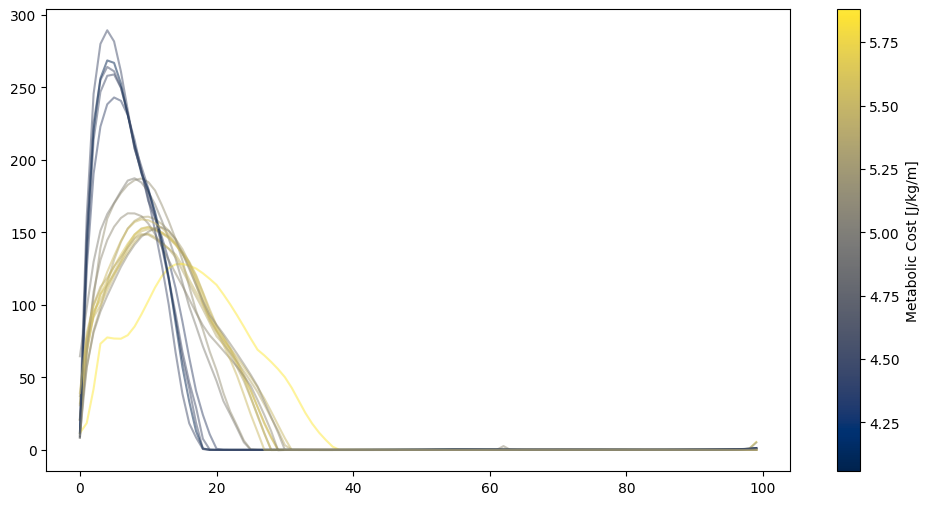

In [38]:
speed = 4.13
fig, ax = plt.subplots(figsize=(12, 6))
df_test = df2[np.isclose(df2.speed, speed)]
cmap = plt.get_cmap('cividis')
norm = plt.Normalize(vmin=df_test['metabolicCost'].min(), vmax=df_test['metabolicCost'].max())
for i, row in df_test.iterrows():
    plt.plot(row['grf']['grf_y']*180/np.pi, color=cmap(norm(row['metabolicCost'])), alpha=0.5)
plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='Metabolic Cost [J/kg/m]')

## Gait patterns: Walking, Running and Stiff Running

Stiff Running: [https://journals.plos.org/ploscompbiol/article?id=10.1371/journal.pcbi.1011410]

/var/folders/zp/1cs5lqq978n6gd_m465gfm840000gn/T/ipykernel_14621/3400597691.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subset
/var/folders/zp/1cs5lqq978n6gd_m465gfm840000gn/T/ipykernel_14621/3400597691.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{y:.0%}" for y in ax.get_yticks()])


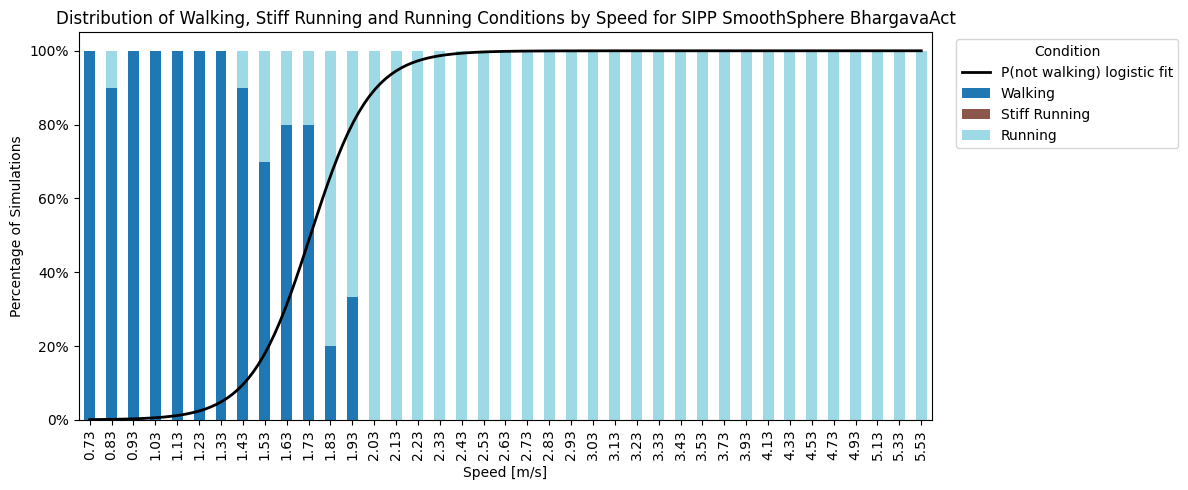

/var/folders/zp/1cs5lqq978n6gd_m465gfm840000gn/T/ipykernel_14621/3400597691.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subset
/var/folders/zp/1cs5lqq978n6gd_m465gfm840000gn/T/ipykernel_14621/3400597691.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{y:.0%}" for y in ax.get_yticks()])


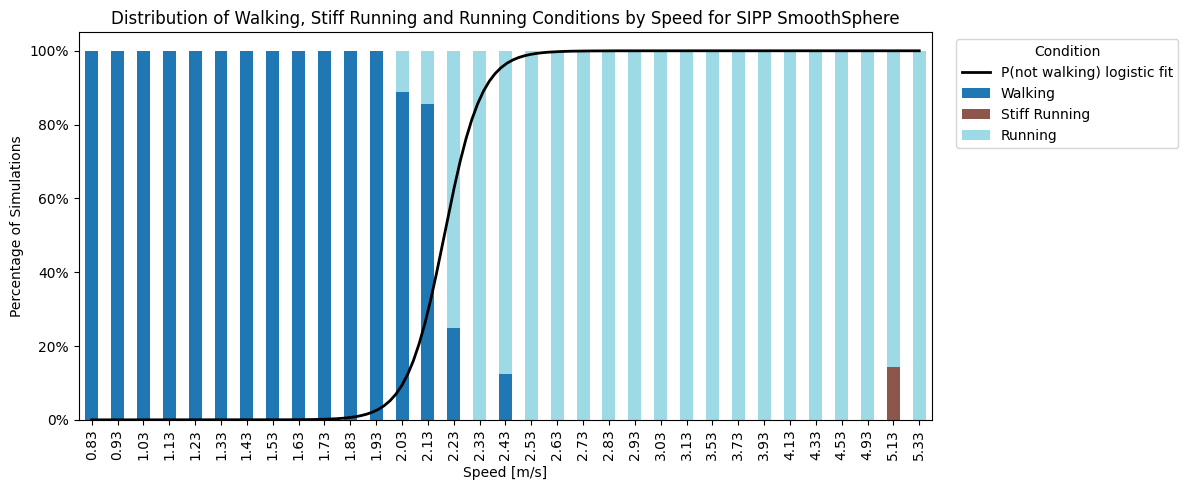

/var/folders/zp/1cs5lqq978n6gd_m465gfm840000gn/T/ipykernel_14621/3400597691.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subset
/var/folders/zp/1cs5lqq978n6gd_m465gfm840000gn/T/ipykernel_14621/3400597691.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{y:.0%}" for y in ax.get_yticks()])


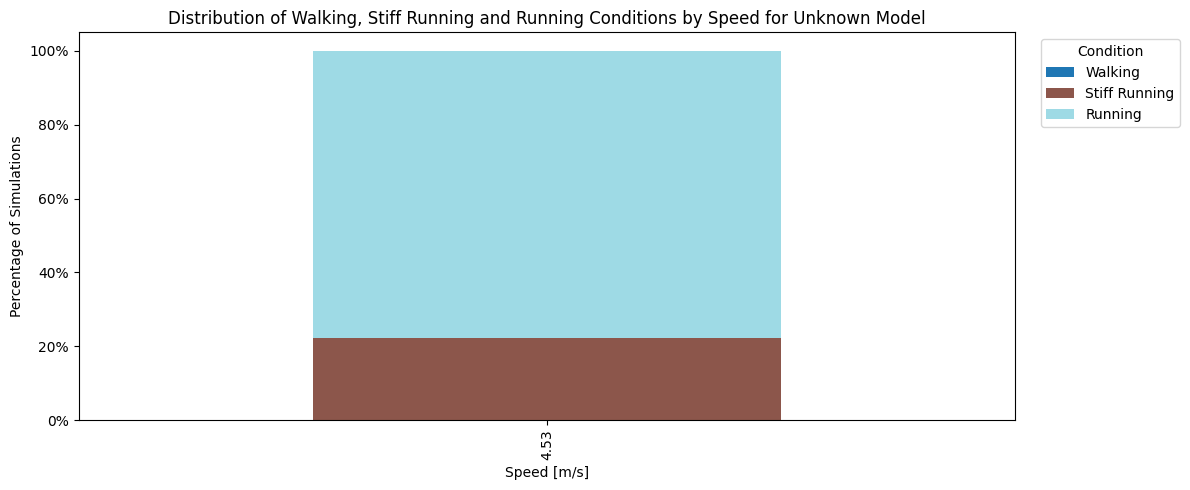

/var/folders/zp/1cs5lqq978n6gd_m465gfm840000gn/T/ipykernel_14621/3400597691.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subset
/var/folders/zp/1cs5lqq978n6gd_m465gfm840000gn/T/ipykernel_14621/3400597691.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{y:.0%}" for y in ax.get_yticks()])


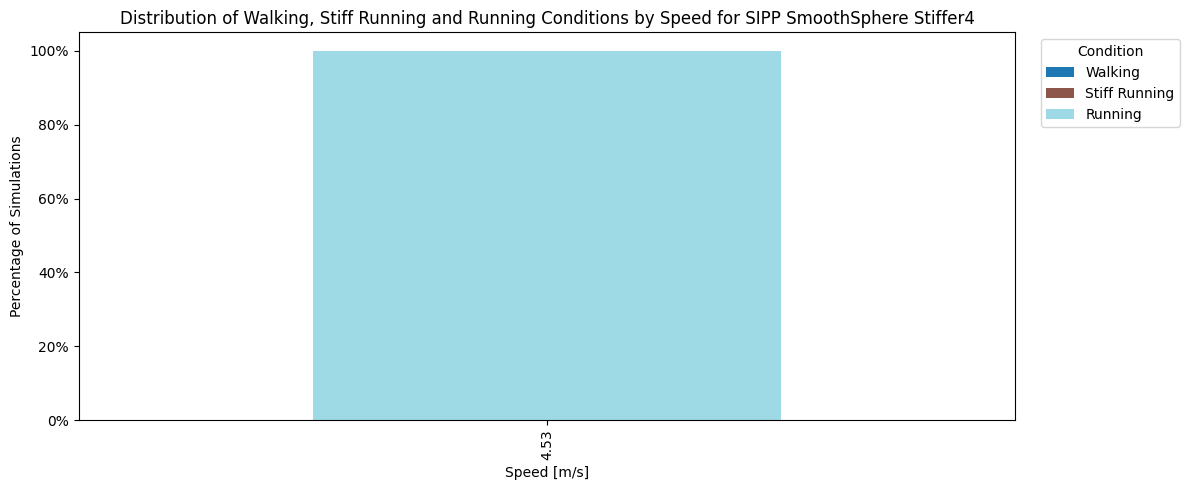

In [95]:
# Condition walking: GRF at node 50 > 0.2 BW
# Condition stiff running: not walking and knee angle at node 0 < 10 degrees
    
df2 = df[df['converged'] == True].copy()
df2['is_walking'] = df2.apply(lambda row: np.mean([row['grf']['grf_y'][50]]) > 0.2, axis=1)
df2['is_stiff_running'] = df2.apply(lambda row: (not row['is_walking']) and (row['angles']['knee_angle'][0]*180/np.pi > -10), axis=1)
df2['not_walking'] = (~df2['is_walking']).astype(float)
# Plot the distribution of walking, stiff running and other conditions by speed

from sklearn.linear_model import LogisticRegression

for model in df2['msk_model'].unique():
    subset = df2[df2['msk_model'] == model]
    condition_counts = (
    subset
    .groupby(['speed'])
    .apply(lambda x: pd.Series({
        'Walking': x['is_walking'].sum(),
        'Stiff Running': x['is_stiff_running'].sum(),
        'Running': len(x) - x['is_walking'].sum() - x['is_stiff_running'].sum()
    })))
    condition_counts = condition_counts.apply(lambda x: x / x.sum(), axis=1)
    ax = condition_counts.plot(kind='bar', stacked=True, figsize=(12, 5), colormap='tab20')#,hue="msk_model")
    ax.set_xlabel('Speed [m/s]')
    ax.set_ylabel('Percentage of Simulations')
    ax.set_title('Distribution of Walking, Stiff Running and Running Conditions by Speed')
    ax.set_xticklabels([f"{x:.2f}" for x in condition_counts.index], rotation=90)
    ax.set_yticklabels([f"{y:.0%}" for y in ax.get_yticks()])

    # Logistic-regression fit of P(not walking) vs. speed -- the walk-to-run transition --
    # overlaid on this model's bars. Bars sit at integer x-positions in speed-sorted order
    # (not the real speed values), so map speed -> bar position by linear interpolation over
    # the known grid, same trick used for the strike-pattern transition plot above.
    if subset['not_walking'].nunique() >= 2:
        bar_speeds = condition_counts.index.to_numpy()
        bar_xpos = np.arange(len(bar_speeds))
        clf = LogisticRegression(C=100).fit(subset[['speed']], subset['not_walking'])
        speed_grid = pd.DataFrame({'speed': np.linspace(subset['speed'].min(), subset['speed'].max(), 200)})
        proba = clf.predict_proba(speed_grid)[:, 1]
        x = np.interp(speed_grid['speed'], bar_speeds, bar_xpos)
        ax.plot(x, proba, color='black', linewidth=2, label='P(not walking) logistic fit')

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, title='Condition', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.title(f'Distribution of Walking, Stiff Running and Running Conditions by Speed for {model}')
    plt.tight_layout()
    plt.show()

    

In [96]:
condition_counts

,Walking,Stiff Running,Running
speed,,,
4.53,0.0,0.0,1.0


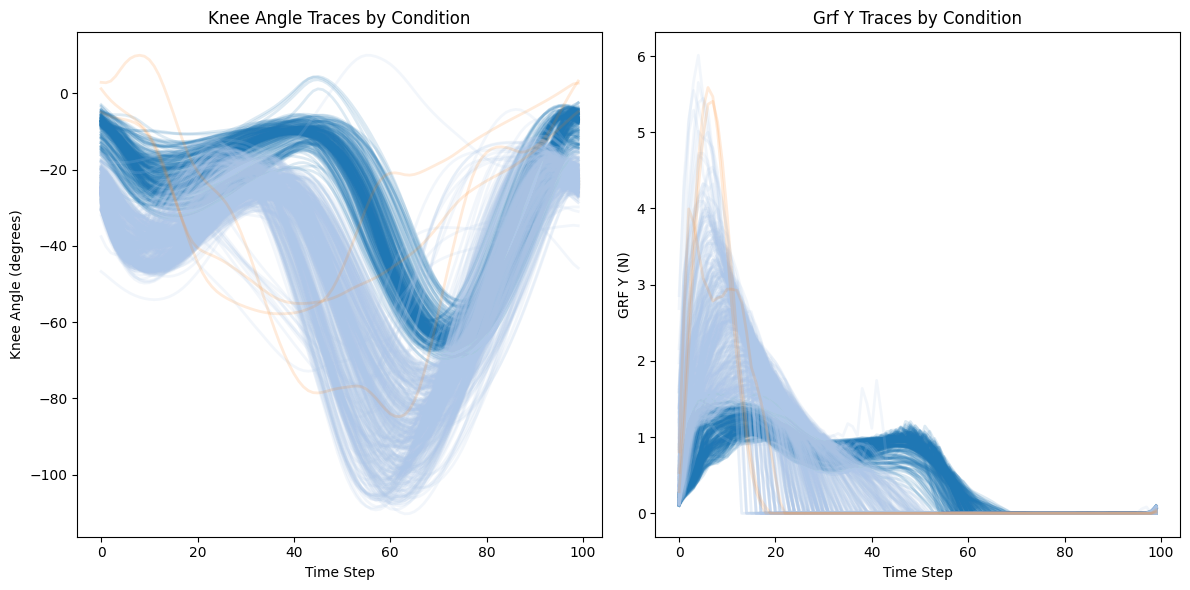

In [97]:
# Show traces for each: knee angle and y-GRF with a hue for condition
df2['condition'] = df2.apply(lambda row: 'Walking' if row['is_walking'] else ('Stiff Running' if row['is_stiff_running'] else 'Running'), axis=1)
fig = plt.figure(figsize=(12, 6))
cmap = plt.get_cmap('tab20')
for i, joint in enumerate(['knee_angle', 'grf_y']): 
    plt.subplot(1, 2, i+1)
    for condition, color in zip(df2['condition'].unique(), cmap.colors):
        subset = df2[df2['condition'] == condition]
        if not subset.empty:
            if joint == 'knee_angle':
                list_of_traces = np.array([row['angles'][joint] for i,row in subset.iterrows()]) * 180/np.pi
                mean_trace = np.mean(list_of_traces, axis=0)
                std_trace = np.std(list_of_traces, axis=0)
                plt.plot(list_of_traces.T, label=f'{condition}', linewidth=2, color=color, alpha=0.15)
                plt.ylabel('Knee Angle (degrees)')
            else:
                list_of_traces = np.array([row['grf'][f'grf_y'] for i,row in subset.iterrows()])
                mean_trace = np.mean(list_of_traces, axis=0)
                std_trace = np.std(list_of_traces, axis=0)  
                plt.plot(list_of_traces.T, label=f'{condition}', linewidth=2, color=color, alpha=0.15)
                plt.ylabel('GRF Y (N)')
    plt.title(f'{joint.replace("_", " ").title()} Traces by Condition')
    plt.xlabel('Time Step')
plt.tight_layout()
plt.show()

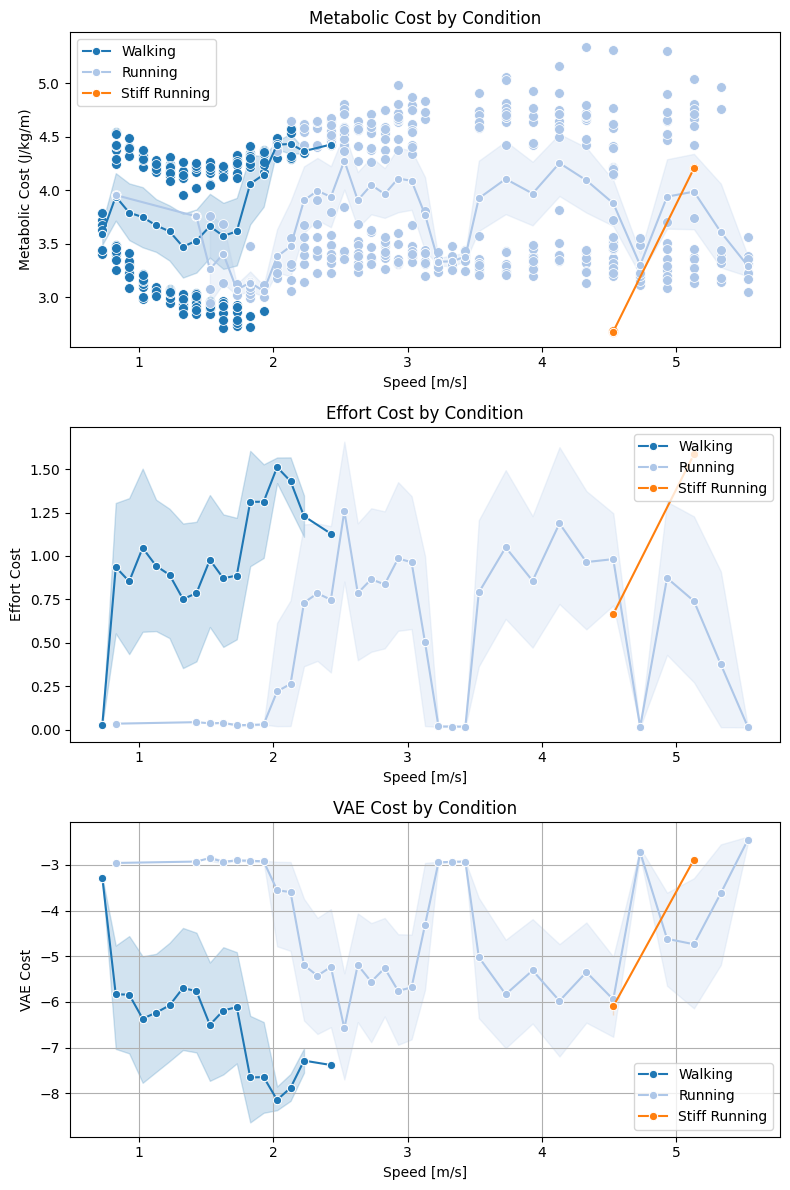

In [98]:
# Three metcost traces: Walking, Stiff Running, Running
#df2 = df2[df2['msk_model'] == 'SIPP SmoothSphere'].copy()
fig = plt.figure(figsize=(8, 12))
fig.add_subplot(3, 1, 1)
for condition, color in zip(df2['condition'].unique(), cmap.colors):
    subset = df2[df2['condition'] == condition]
    sns.lineplot(x='speed', y='metabolicCostBhargava', data=subset, label=f'{condition}', color=color, marker='o')
    sns.scatterplot(x='speed', y='metabolicCostBhargava', data=subset, color=color, s=50)
    
plt.title('Metabolic Cost by Condition')
plt.xlabel('Speed [m/s]')
plt.ylabel('Metabolic Cost (J/kg/m)')
fig.add_subplot(3, 1, 2)
df2['Effort'] = df2['objectives'].apply(lambda x: sum([obj['weightedValue'] for obj in x if obj['name'] in ['effortTermMusclesAct',"effortTermTorques"]]))
df2['VAE'] = df2['objectives'].apply(lambda x: sum([obj['weightedValue'] for obj in x if obj['name'] == 'vaeReconstructionTerm']))
for condition, color in zip(df2['condition'].unique(), cmap.colors):
    subset = df2[df2['condition'] == condition]
    sns.lineplot(x='speed', y='Effort', data=subset, label=f'{condition}', color=color, marker='o')
plt.title('Effort Cost by Condition')
plt.xlabel('Speed [m/s]')
plt.ylabel('Effort Cost')
fig.add_subplot(3, 1, 3)
for condition, color in zip(df2['condition'].unique(), cmap.colors):
    subset = df2[df2['condition'] == condition]
    sns.lineplot(x='speed', y='VAE', data=subset, label=f'{condition}', color=color, marker='o')
plt.title('VAE Cost by Condition')
plt.xlabel('Speed [m/s]')
plt.ylabel('VAE Cost')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

## Muscle Activations

In [77]:
# Explore

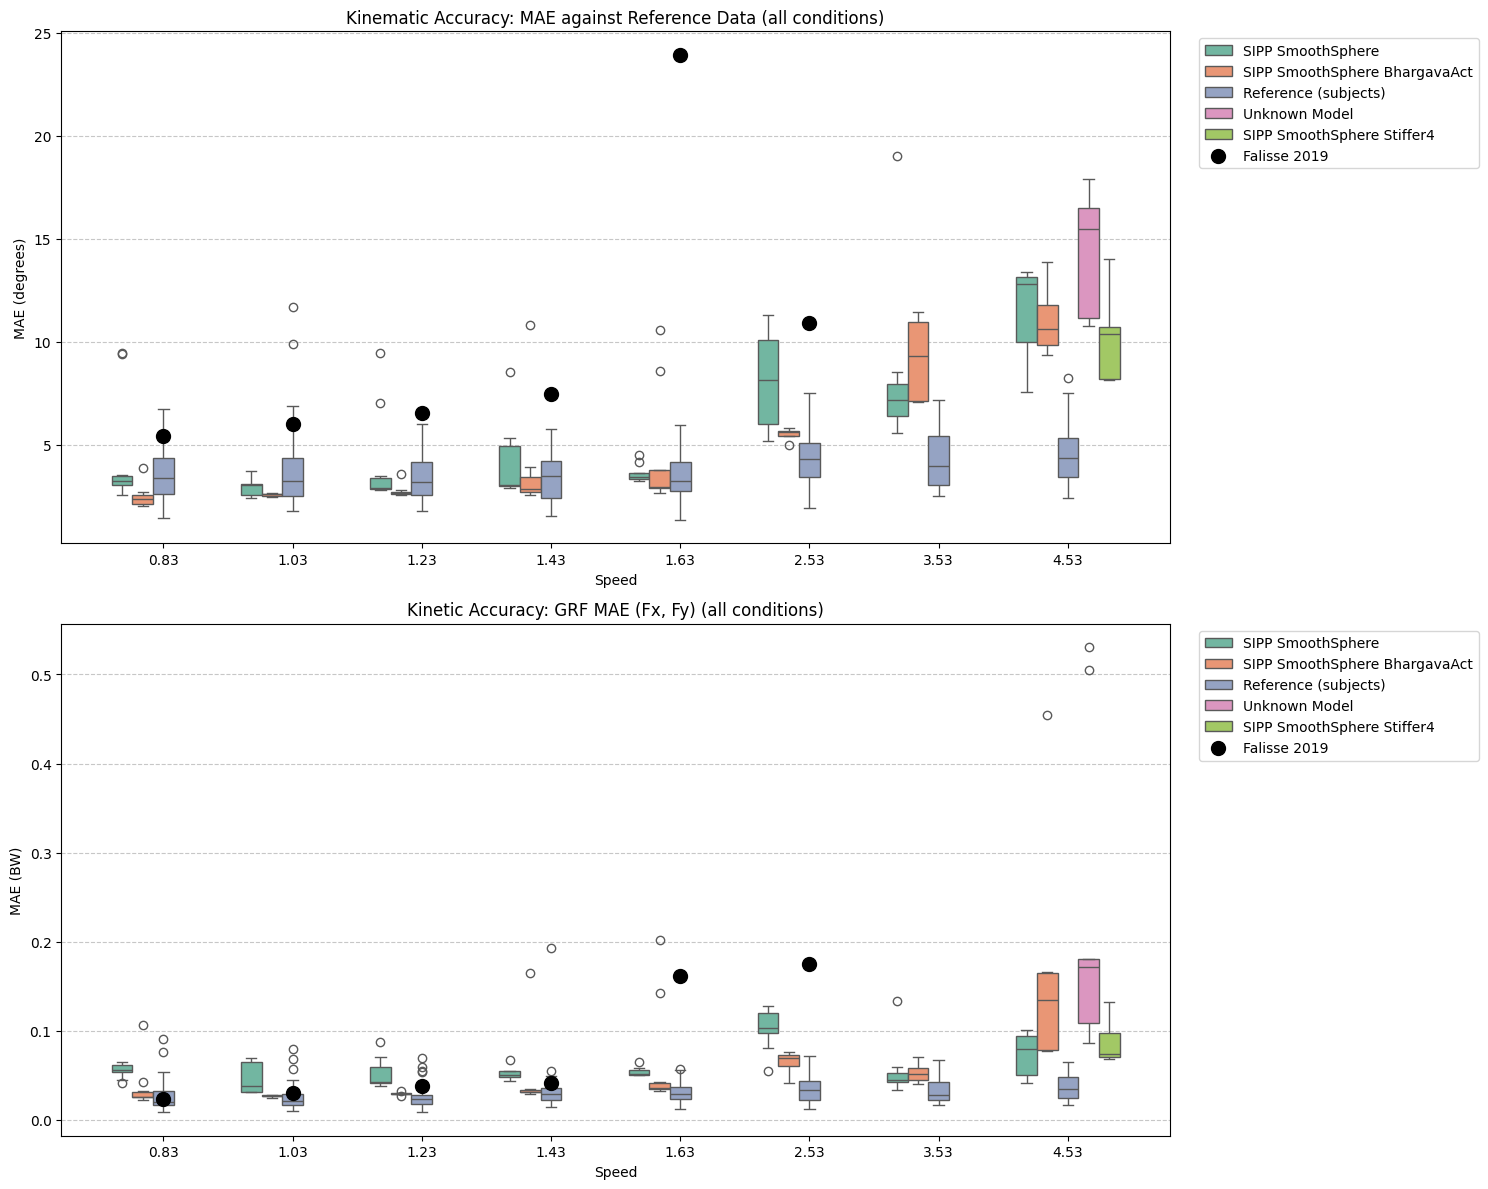

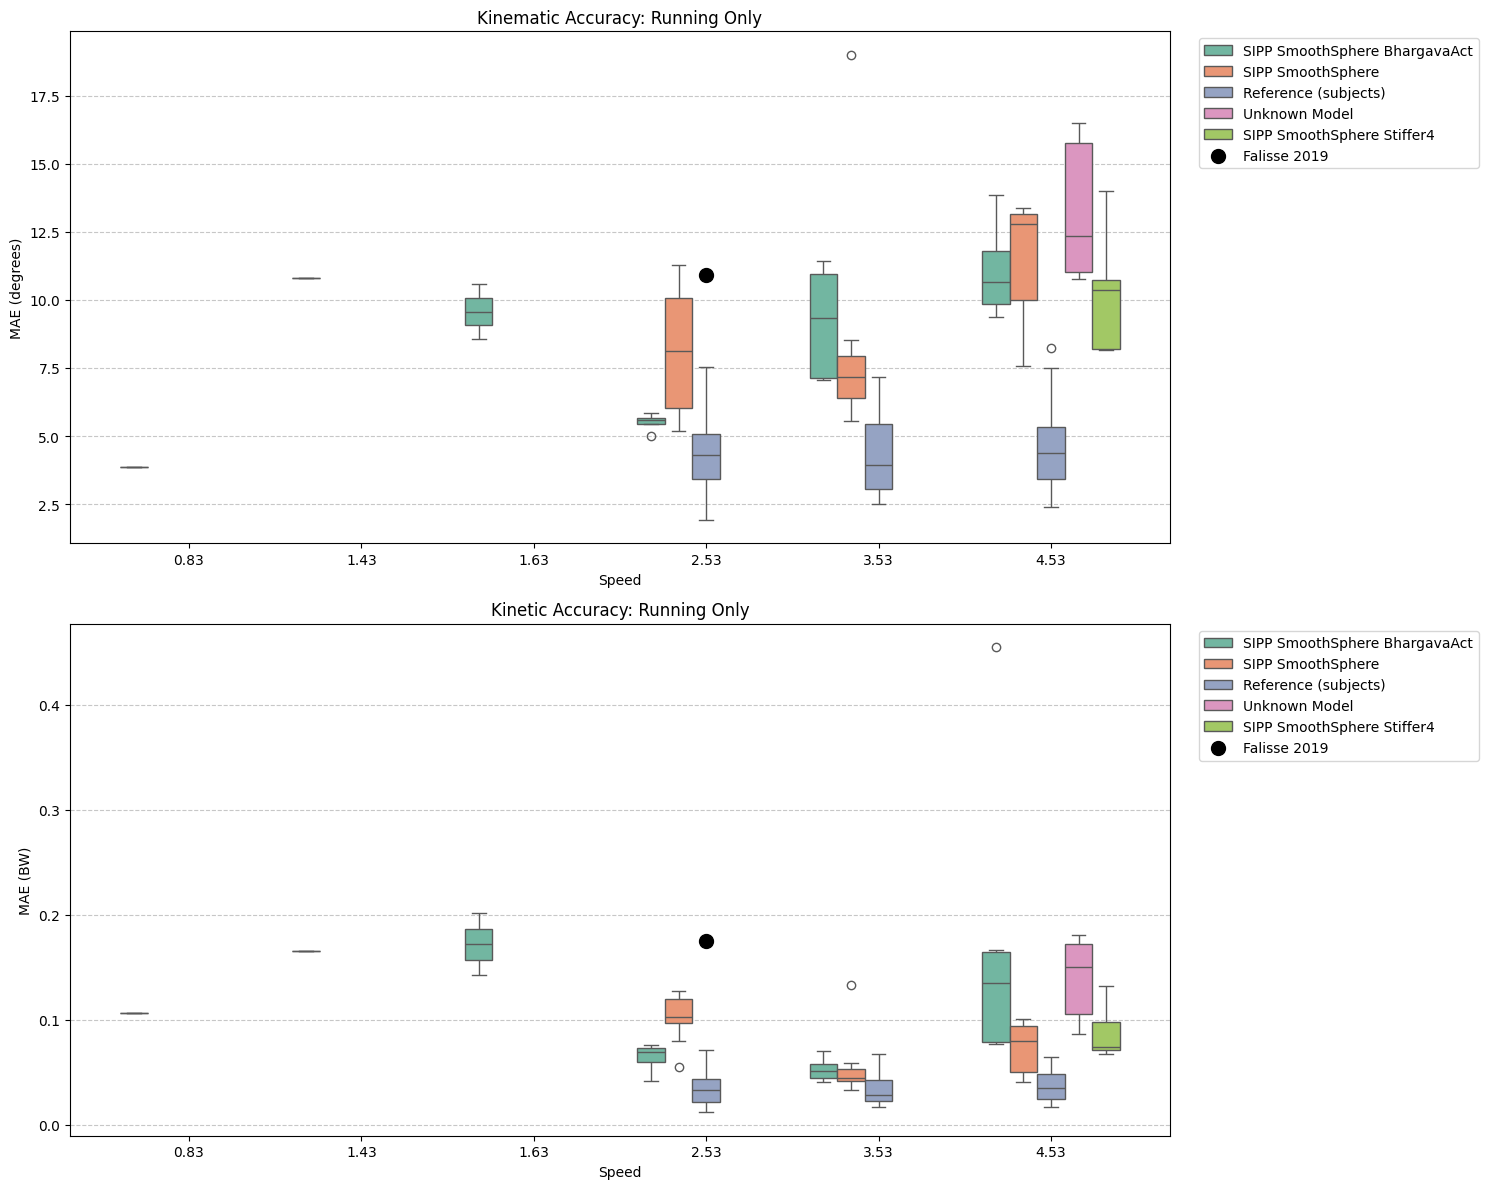

In [90]:
# Boxplot compare against reference data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import loadmat
import os
import importlib
import data_utils

# Ensure we have the latest data_utils logic
importlib.reload(data_utils)
from data_utils import get_reference_data

# Align and calculate accuracy for our data
target_speeds = [0.83, 1.03, 1.23, 1.43, 1.63, 2.53, 3.53, 4.53]
results = []

import gait_metrics as gm
from gait_loading import load_gaitdynamics, load_gaitencoder, load_reference_subject_curves, load_gaitnet

# Alignment + MAE and the per-subject reference loader live in the shared modules now.
# (see gait_metrics.align_and_maes and gait_loading.load_reference_subject_curves)
get_best_alignment_and_maes = gm.align_and_maes

for speed in target_speeds:
    ref_data = get_reference_data(speed)
    if ref_data:
        ref_angles = np.array([ref_data['hip']['mean'], ref_data['knee']['mean'], ref_data['ankle']['mean']]).T
        ref_grf = np.array([ref_data['Fx']['mean'], ref_data['Fy']['mean']]).T
    else:
        ref_angles, ref_grf = None, None
    
    # 1. Our simulations
    subset = df2[np.isclose(df2['speed'], speed) & (df2['converged'] == True)]
    for _, row in subset.iterrows():
        # Determine condition based on gait characteristics
        is_walking = np.mean([row['grf']['grf_y'][50]]) > 0.2
        is_stiff_running = (not is_walking) and (row['angles']['knee_angle'][0]*180/np.pi > -10)
        condition = 'Walking' if is_walking else ('Stiff Running' if is_stiff_running else 'Running')
        
        sim_angles = np.array([row['angles'][j] for j in ['hip_flexion', 'knee_angle', 'ankle_angle']]).T * 180/np.pi
        sim_grf = np.array([row['grf']['grf_x'], row['grf']['grf_y']]).T
        
        mae_angles, mae_grf = get_best_alignment_and_maes(sim_angles, sim_grf, ref_angles, ref_grf)
        results.append({
            'Speed': speed,
            'Model': row['msk_model'],
            'Condition': condition,
            'Kinematic MAE (deg)': mae_angles,
            'GRF MAE (BW)': mae_grf
        })

    # 2. Falisse Baseline (up to 2.73 m/s)
    f_q, f_grf = get_falisse_sim(speed) # Uses the global function defined earlier
    if f_q is not None:
        # f_q is already in degrees, do not convert to radians
        mae_angles, mae_grf = get_best_alignment_and_maes(f_q, f_grf, ref_angles, ref_grf)
        results.append({
            'Speed': speed,
            'Model': 'Falisse 2019',
            'Condition': 'Running' if speed > 2 else 'Walking',
            'Kinematic MAE (deg)': mae_angles,
            'GRF MAE (BW)': mae_grf
        })

    # 2b. Falisse 2022 benchmark (same unified format as our sims), added as its
    # own Model hue level. Match benchmark trials whose speed is within 0.05 m/s of
    # this group's reference speed (reference speeds are round -- 0.8, 1.0, ...; our
    # simulations just run ever so slightly faster).
    ref_speed = min([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 2.5, 3.5, 4.5], key=lambda s: abs(s - speed))
    #for _, row_b in bench[np.abs(bench['speed'] - ref_speed) <= 0.05].iterrows():
    #    sim_angles, sim_grf = gm.trial_curves(row_b)
    #    mae_angles, mae_grf = get_best_alignment_and_maes(sim_angles, sim_grf, ref_angles, ref_grf)
    #    results.append({
    #        'Speed': speed,
    #        'Model': 'Falisse 2022',
    #        'Condition': gm.classify_gait(row_b),
    #        'Kinematic MAE (deg)': mae_angles,
    #        'GRF MAE (BW)': mae_grf
    #    })
#
    #gait_encoder_df = load_gaitencoder(latent='prior')
    #for _, row_b in gait_encoder_df[np.abs(gait_encoder_df['speed'] - ref_speed) <= 0.05].iterrows():
    #    sim_angles, sim_grf = gm.trial_curves(row_b)
    #    mae_angles, mae_grf = get_best_alignment_and_maes(sim_angles, sim_grf, ref_angles, ref_grf)
    #    results.append({
    #        'Speed': speed,
    #        'Model': 'GaitEncoder',
    #        'Condition': 'Running' if speed > 2 else 'Walking',
    #        'Kinematic MAE (deg)': mae_angles,
    #        'GRF MAE (BW)': mae_grf
    #    })
#
    #gaitnet_df = load_gaitnet()
    #for _, row_b in gaitnet_df[np.abs(gaitnet_df['speed'] - ref_speed) <= 0.05].iterrows():
    #    sim_angles, sim_grf = gm.trial_curves(row_b)
    #    mae_angles, mae_grf = get_best_alignment_and_maes(sim_angles, sim_grf, ref_angles, ref_grf)
    #    results.append({
    #        'Speed': speed,
    #        'Model': 'GaitNet',
    #        'Condition': 'Running' if speed > 2 else 'Walking',
    #        'Kinematic MAE (deg)': mae_angles,
    #        'GRF MAE (BW)': mae_grf
    #    })
#
    #gaitdynamics_df = load_gaitdynamics()#mode='inpaint')
    #for _, row_b in gaitdynamics_df[np.abs(gaitdynamics_df['speed'] - ref_speed) <= 0.05].iterrows():
    #    sim_angles, sim_grf = gm.trial_curves(row_b)
    #    mae_angles, mae_grf = get_best_alignment_and_maes(sim_angles, sim_grf, ref_angles, ref_grf)
    #    results.append({
    #        'Speed': speed,
    #        'Model': 'GaitDynamics',
    #        'Condition': gm.classify_gait(row_b),
    #        'Kinematic MAE (deg)': mae_angles,
    #        'GRF MAE (BW)': mae_grf
    #    })

    # 3. Reference data as another experiment: each individual reference subject file,
    # aligned and scored against the same reference mean our simulations are scored against.
    for ref_angles_subj, ref_grf_subj in load_reference_subject_curves(speed):
        mae_angles, mae_grf = get_best_alignment_and_maes(ref_angles_subj, ref_grf_subj, ref_angles, ref_grf)
        results.append({
            'Speed': speed,
            'Model': 'Reference (subjects)',
            'Condition': 'Running' if speed > 2 else 'Walking',
            'Kinematic MAE (deg)': mae_angles,
            'GRF MAE (BW)': mae_grf
        })


df_plot = pd.DataFrame(results)

# Create mapping of Speed to x-position for accurate scatter plot alignment
speed_to_xpos = {speed: i for i, speed in enumerate(sorted(df_plot['Speed'].unique()))}

# Create the plots
plt.figure(figsize=(15, 12))

# Kinematics Accuracy
plt.subplot(2, 1, 1)
df_plot_no_falisse = df_plot[df_plot['Model'] != 'Falisse 2019']
sns.boxplot(x='Speed', y='Kinematic MAE (deg)', hue='Model', data=df_plot_no_falisse, palette='Set2')
# Add Falisse as scatter points at correct x-positions
df_falisse = df_plot[df_plot['Model'] == 'Falisse 2019']
falisse_xpos = [speed_to_xpos[speed] for speed in df_falisse['Speed']]
plt.scatter(falisse_xpos, df_falisse['Kinematic MAE (deg)'], color='black', s=100, marker='o', label='Falisse 2019', zorder=5)
plt.title('Kinematic Accuracy: MAE against Reference Data (all conditions)')
plt.ylabel('MAE (degrees)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# Kinetic Accuracy
plt.subplot(2, 1, 2)
sns.boxplot(x='Speed', y='GRF MAE (BW)', hue='Model', data=df_plot_no_falisse, palette='Set2')
# Add Falisse as scatter points at correct x-positions
plt.scatter(falisse_xpos, df_falisse['GRF MAE (BW)'], color='black', s=100, marker='o', label='Falisse 2019', zorder=5)
plt.title('Kinetic Accuracy: GRF MAE (Fx, Fy) (all conditions)')
plt.ylabel('MAE (BW)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Additional plot: Correct style (Running only) 
df_plot_correct = df_plot[df_plot['Condition'] == 'Running']
df_plot_correct_no_falisse = df_plot_correct[df_plot_correct['Model'] != 'Falisse 2019']
df_falisse_correct = df_plot_correct[df_plot_correct['Model'] == 'Falisse 2019']

# Update speed_to_xpos mapping for running-only data
speed_to_xpos_running = {speed: i for i, speed in enumerate(sorted(df_plot_correct['Speed'].unique()))}
falisse_xpos_running = [speed_to_xpos_running[speed] for speed in df_falisse_correct['Speed']]

plt.figure(figsize=(15, 12))

# Kinematics Accuracy (Correct Style Only)
plt.subplot(2, 1, 1)
sns.boxplot(x='Speed', y='Kinematic MAE (deg)', hue='Model', data=df_plot_correct_no_falisse, palette='Set2')
# Add Falisse as scatter points at correct x-positions
plt.scatter(falisse_xpos_running, df_falisse_correct['Kinematic MAE (deg)'], color='black', s=100, marker='o', label='Falisse 2019', zorder=5)
plt.title('Kinematic Accuracy: Running Only')
plt.ylabel('MAE (degrees)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# Kinetic Accuracy (Correct Style Only)
plt.subplot(2, 1, 2)
sns.boxplot(x='Speed', y='GRF MAE (BW)', hue='Model', data=df_plot_correct_no_falisse, palette='Set2')
# Add Falisse as scatter points at correct x-positions
plt.scatter(falisse_xpos_running, df_falisse_correct['GRF MAE (BW)'], color='black', s=100, marker='o', label='Falisse 2019', zorder=5)
plt.title('Kinetic Accuracy: Running Only')
plt.ylabel('MAE (BW)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()



Mean MAE by model and condition (Walking/Running):
                                         Kinematic MAE (deg)  GRF MAE (BW)
Model                         Condition                                   
Falisse 2019                  Running                 10.925         0.175
                              Walking                  9.869         0.059
Reference (subjects)          Running                  4.446         0.035
                              Walking                  3.513         0.029
SIPP SmoothSphere             Running                  9.143         0.081
                              Walking                  3.830         0.052
SIPP SmoothSphere BhargavaAct Running                  9.046         0.106
                              Walking                  2.741         0.030
SIPP SmoothSphere Stiffer4    Running                 10.289         0.089
Unknown Model                 Running                 13.303         0.139

Pivoted view (easier comparison):
              

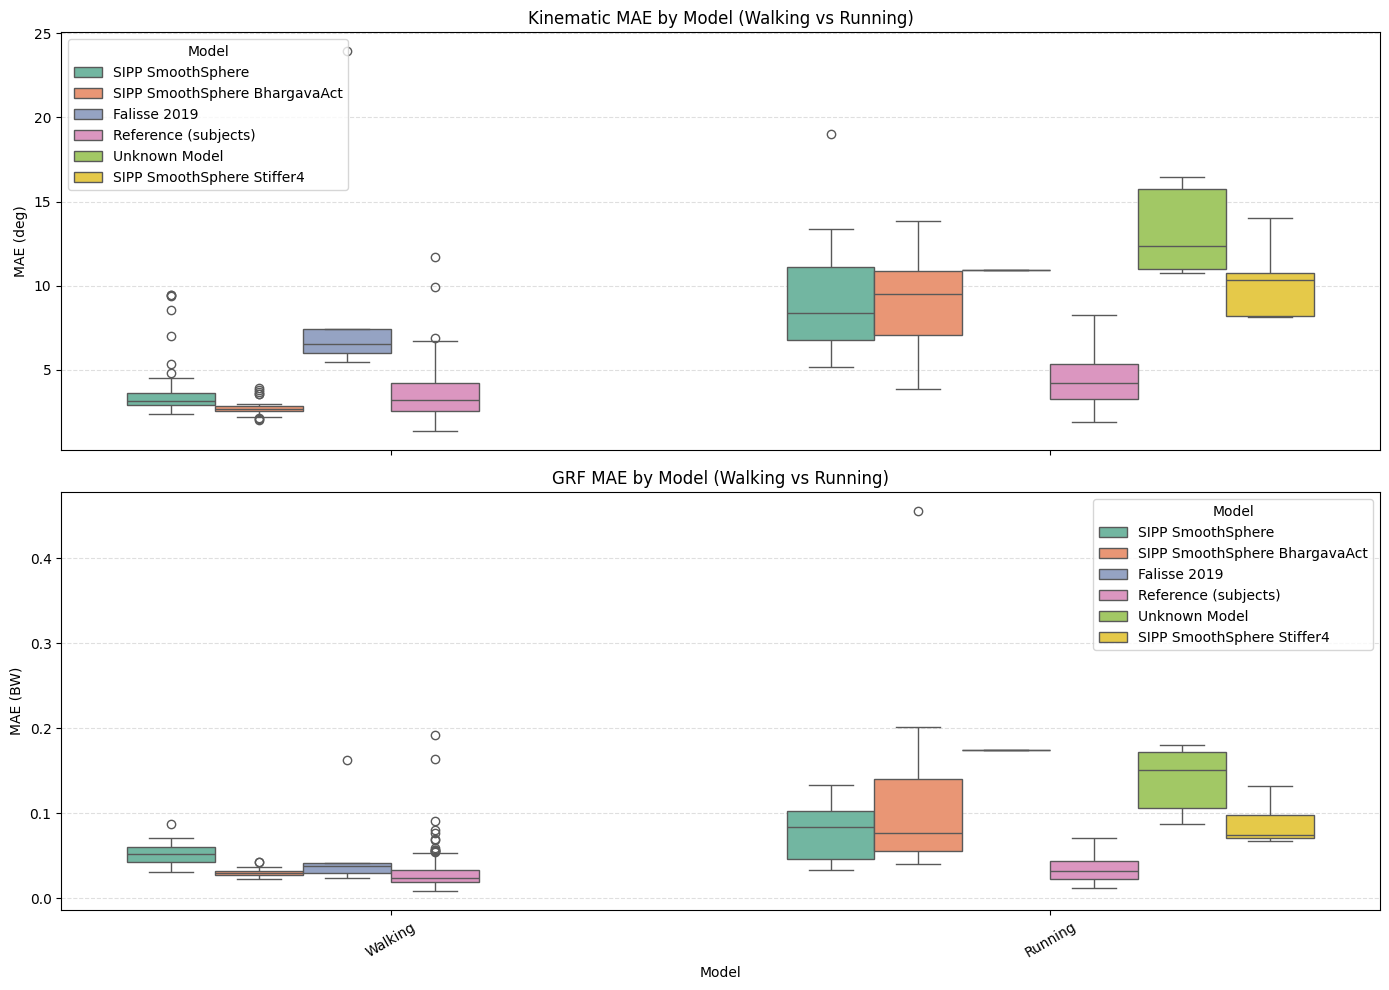

In [91]:
# Mean MAE for Walking vs Running, per model
conditions_to_show = ['Walking', 'Running']

mae_summary = (
    df_plot[df_plot['Condition'].isin(conditions_to_show)]
    .groupby(['Model', 'Condition'])[['Kinematic MAE (deg)', 'GRF MAE (BW)']]
    .mean()
    .sort_index()
)

print("Mean MAE by model and condition (Walking/Running):")
print(mae_summary.round(3))

print("\nPivoted view (easier comparison):")
print(
    mae_summary.unstack('Condition').round(3)
)

df_box = df_plot[df_plot['Condition'].isin(conditions_to_show)].copy()
model_order = sorted(df_box['Model'].unique())

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

sns.boxplot(
    data=df_box,
    hue='Model',
    y='Kinematic MAE (deg)',
    x='Condition',
    ax=axes[0],
    palette='Set2'
)
axes[0].set_title('Kinematic MAE by Model (Walking vs Running)')
axes[0].set_ylabel('MAE (deg)')
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

sns.boxplot(
    data=df_box,
    hue='Model',
    y='GRF MAE (BW)',
    x='Condition',
    ax=axes[1],
    palette='Set2'
)
axes[1].set_title('GRF MAE by Model (Walking vs Running)')
axes[1].set_ylabel('MAE (BW)')
axes[1].set_xlabel('Model')
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

for ax in axes:
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [174]:
load_gaitdynamics()#mode='inpaint')

,source,msk_model,speed,converged,angles,grf,metabolicCost,speed_achieved,dur,duty_factor,i_gen
0,gaitdynamics,GaitDynamics,0.8,True,pelvis_tilt pelvis_list pelvis_rotation ...,grf_x grf_y grf_z 0 -0.003079 ...,NaN,0.8,1.06,0.641509,6
1,gaitdynamics,GaitDynamics,0.8,True,pelvis_tilt pelvis_list pelvis_rotation ...,grf_x grf_y grf_z 0 0.000926 ...,NaN,0.8,0.83,0.891566,90
2,gaitdynamics,GaitDynamics,0.8,True,pelvis_tilt pelvis_list pelvis_rotation ...,grf_x grf_y grf_z 0 -0.008815 ...,NaN,0.8,1.04,0.615385,86
3,gaitdynamics,GaitDynamics,0.8,True,pelvis_tilt pelvis_list pelvis_rotation ...,grf_x grf_y grf_z 0 -0.000210 ...,NaN,0.8,1.24,0.620968,84
4,gaitdynamics,GaitDynamics,0.8,True,pelvis_tilt pelvis_list pelvis_rotation ...,grf_x grf_y grf_z 0 0.018380 ...,NaN,0.8,0.96,0.531250,80
...,...,...,...,...,...,...,...,...,...,...,...
346,gaitdynamics,GaitDynamics,2.5,True,pelvis_tilt pelvis_list pelvis_rotation ...,grf_x grf_y grf_z 0 -0.159225 ...,NaN,2.5,0.68,0.308824,26
347,gaitdynamics,GaitDynamics,2.5,True,pelvis_tilt pelvis_list pelvis_rotation ...,grf_x grf_y grf_z 0 -0.110800 ...,NaN,2.5,0.73,0.328767,25
348,gaitdynamics,GaitDynamics,2.5,True,pelvis_tilt pelvis_list pelvis_rotation ...,grf_x grf_y grf_z 0 0.020650 ...,NaN,2.5,0.69,0.347826,24
349,gaitdynamics,GaitDynamics,2.5,True,pelvis_tilt pelvis_list pelvis_rotation ...,grf_x grf_y grf_z 0 -0.109476 ...,NaN,2.5,0.52,0.423077,50


In [175]:
gaitdynamics_df

,source,msk_model,speed,converged,angles,grf,metabolicCost,speed_achieved,dur,duty_factor,i_gen
0,gaitdynamics,GaitDynamics,0.8,True,pelvis_tilt pelvis_list pelvis_rotation ...,grf_x grf_y grf_z 0 -0.003079 ...,NaN,0.8,1.06,0.641509,6
1,gaitdynamics,GaitDynamics,0.8,True,pelvis_tilt pelvis_list pelvis_rotation ...,grf_x grf_y grf_z 0 0.000926 ...,NaN,0.8,0.83,0.891566,90
2,gaitdynamics,GaitDynamics,0.8,True,pelvis_tilt pelvis_list pelvis_rotation ...,grf_x grf_y grf_z 0 -0.008815 ...,NaN,0.8,1.04,0.615385,86
3,gaitdynamics,GaitDynamics,0.8,True,pelvis_tilt pelvis_list pelvis_rotation ...,grf_x grf_y grf_z 0 -0.000210 ...,NaN,0.8,1.24,0.620968,84
4,gaitdynamics,GaitDynamics,0.8,True,pelvis_tilt pelvis_list pelvis_rotation ...,grf_x grf_y grf_z 0 0.018380 ...,NaN,0.8,0.96,0.531250,80
...,...,...,...,...,...,...,...,...,...,...,...
346,gaitdynamics,GaitDynamics,2.5,True,pelvis_tilt pelvis_list pelvis_rotation ...,grf_x grf_y grf_z 0 -0.159225 ...,NaN,2.5,0.68,0.308824,26
347,gaitdynamics,GaitDynamics,2.5,True,pelvis_tilt pelvis_list pelvis_rotation ...,grf_x grf_y grf_z 0 -0.110800 ...,NaN,2.5,0.73,0.328767,25
348,gaitdynamics,GaitDynamics,2.5,True,pelvis_tilt pelvis_list pelvis_rotation ...,grf_x grf_y grf_z 0 0.020650 ...,NaN,2.5,0.69,0.347826,24
349,gaitdynamics,GaitDynamics,2.5,True,pelvis_tilt pelvis_list pelvis_rotation ...,grf_x grf_y grf_z 0 -0.109476 ...,NaN,2.5,0.52,0.423077,50


In [176]:
df_r = pd.DataFrame(results)

In [177]:
df_r[(df_r.Model == 'GaitNet') & (df_r.Condition == 'Stiff Running')]

,Speed,Model,Condition,Kinematic MAE (deg),GRF MAE (BW)


In [178]:
plt.plot(a['angles'][13, :, 6]*180/np.pi, label='GaitDynamics Inpainted Knee Angle', color='blue')

NameError: name 'a' is not defined

In [54]:
data = """0.83	0.913 ± 0.019 BW @ 41	0.972 ± 0.014 BW @ 43	1.035 ± 0.056 BW @ 46
1.03	0.925 ± 0.033 BW @ 43	0.987 ± 0.016 BW @ 48	1.056 ± 0.067 BW @ 46
1.23	0.939 ± 0.061 BW @ 45	1.019 ± 0.058 BW @ 48	1.080 ± 0.071 BW @ 46
1.43	0.932 ± 0.052 BW @ 45	1.039 ± 0.074 BW @ 48	1.106 ± 0.083 BW @ 46
1.63	0.888 ± 0.018 BW @ 43	1.055 ± 0.030 BW @ 45	1.118 ± 0.090 BW @ 45
"""


In [55]:
data2 = np.fromstring(data.replace('\t', ' ').replace('±', '').replace('@', '').replace('BW', ''), sep=' ').reshape(5,-1)

In [56]:
mean_bhar = data2[:,1]
std_bhar = data2[:,2]
mean_act = data2[:,4]
std_act = data2[:,5]
mean_ref = data2[:,7]
std_ref = data2[:,8]

In [57]:
mean_bhar/mean_ref

array([0.8821256 , 0.87594697, 0.86944444, 0.84267631, 0.79427549])

In [60]:
(mean_act/mean_ref).max()

np.float64(0.9436493738819319)

In [66]:
mean_bhar.mean()

np.float64(0.9194000000000001)

In [108]:
df2[(df2.speed < 4.55) & (df2.speed > 4.5)].groupby('msk_model')['VAE'].mean()

msk_model
SIPP SmoothSphere               -7.363747
SIPP SmoothSphere BhargavaAct   -2.702327
SIPP SmoothSphere Stiffer4      -8.153679
Unknown Model                   -7.049825
Name: VAE, dtype: float64

In [109]:
df2[(df2.speed < 4.55) & (df2.speed > 4.5) & (df2.condition == 'Stiff Running')].groupby('msk_model')['VAE'].mean()

msk_model
Unknown Model   -6.0963
Name: VAE, dtype: float64

In [110]:
df2[(df2.speed < 4.55) & (df2.speed > 4.5) & (df2.condition == 'Running')].groupby('msk_model')['VAE'].mean()

msk_model
SIPP SmoothSphere               -7.363747
SIPP SmoothSphere BhargavaAct   -2.702327
SIPP SmoothSphere Stiffer4      -8.153679
Unknown Model                   -7.322260
Name: VAE, dtype: float64

In [102]:
df2.keys()

Index(['i', 'speed', 'converged', 'info_', 'X', 'objectives', 'constraints',
       'dur', 'metabolicCost', 'metabolicCostBhargava',
       'metabolicCostUmberger', 'metabolicCostHoudijk',
       'metabolicCostMargaria', 'metabolicCostMinetti',
       'metabolicCostLichtwark', 'metabolicCostKim', 'angles', 'grf',
       'msk_model', 'activations', 'source', 'is_walking', 'is_stiff_running',
       'not_walking', 'condition', 'Effort', 'VAE'],
      dtype='object')